## PROYECTO 3

### Imports

In [1]:
import os
import copy
import torch
from torch.utils.data import DataLoader, Subset
import pytorch_lightning as pl
from pytorch_lightning import Trainer
from pytorch_lightning.callbacks import EarlyStopping
from pytorch_lightning.loggers import WandbLogger
from PIL import Image
import matplotlib.pyplot as plt
from collections import defaultdict
from sklearn.model_selection import train_test_split
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from latent_analysis import *
import wandb
from utils.data_module import ButterflyDataModule
from utils.transforms import get_denoising_transform

from utils.visualization import plot_distribution, plot_samples_per_species, display_sample_images
from Unet import UNet
from VAE import VAE
from Unet_Classifier import UNet_Classifier
from latent_analysis import extract_latent_vectors

/work/lnavarro/miniforge3/envs/p3/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/work/lnavarro/miniforge3/envs/p3/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"
/work/lnavarro/miniforge3/envs/p3/lib/python3.10/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: '/work/lnavarro/miniforge3/envs/p3/lib/python3.10/site-packages/torchvision/image.so: undefined symbol: _ZN3c104warnERKNS_7WarningE'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpe

## Dataset

### Análisis de distribución

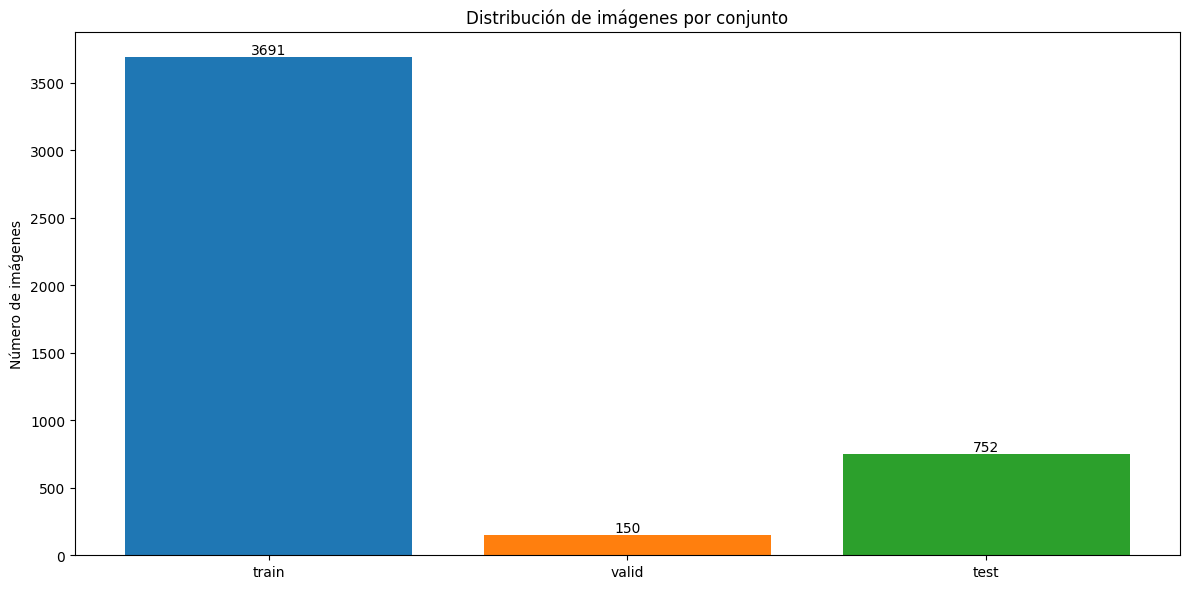

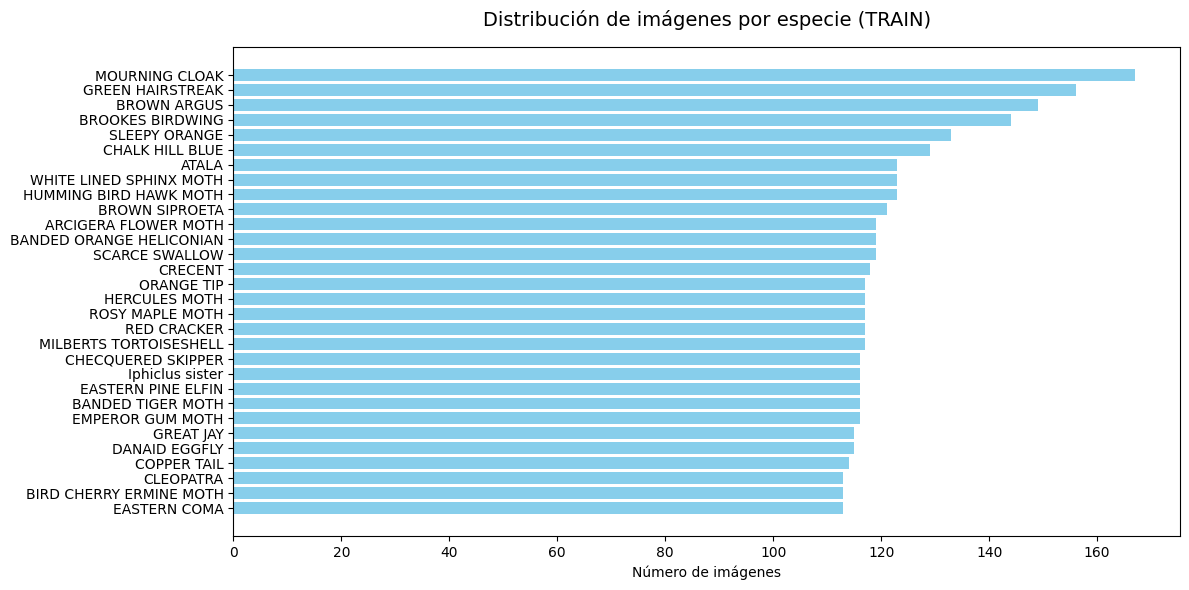

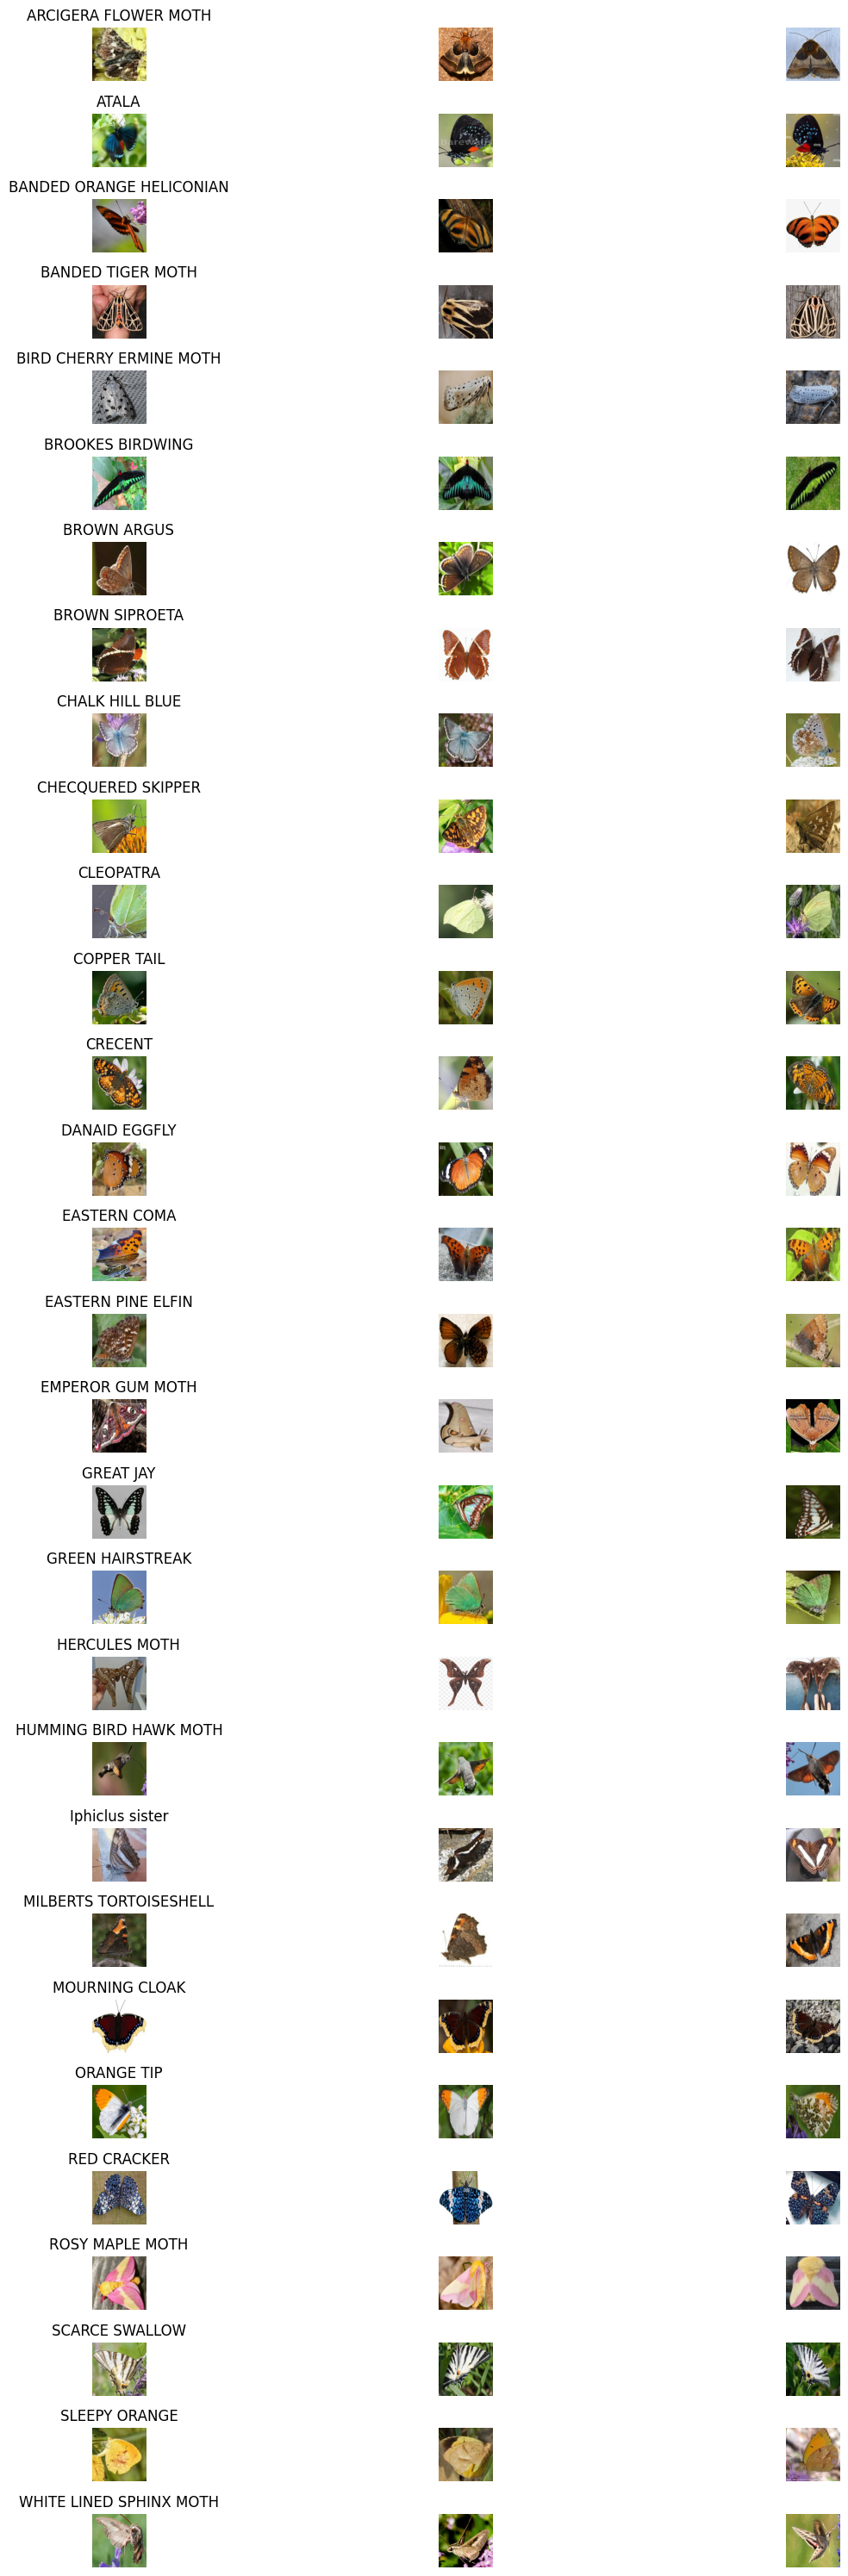

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


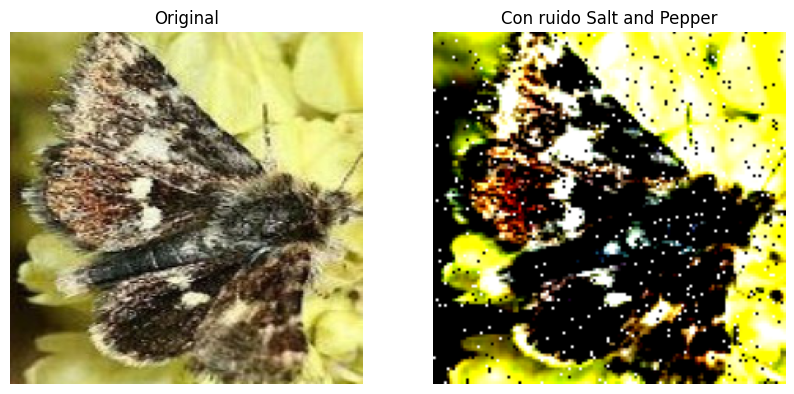

In [5]:
# Análisis de estructura
def analyze_dataset_structure(base_path="/data/lnavarro/p3_data"):
    splits = ['train', 'valid', 'test']
    structure = {split: defaultdict(int) for split in splits}
    
    for split in splits:
        split_path = os.path.join(base_path, split)
        for species in os.listdir(split_path):
            species_path = os.path.join(split_path, species)
            if os.path.isdir(species_path):
                num_images = len([f for f in os.listdir(species_path) if f.lower().endswith('.jpg')])
                structure[split][species] = num_images
    return structure

dataset_structure = analyze_dataset_structure()



# Inicialización y verificación
datamodule = ButterflyDataModule(data_root="/data/lnavarro/p3_data", batch_size=32)
datamodule.setup()

# Visualizaciones
plot_distribution(dataset_structure)
plot_samples_per_species(dataset_structure, split='train')
display_sample_images(datamodule.train_dataset_labeled, n_samples=3)

# Ejemplo de transformación de denoising
sample_img = Image.open(datamodule.train_dataset_labeled.samples[0][0])
noisy_img = get_denoising_transform()(sample_img)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(sample_img)
plt.title("Original")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(noisy_img.permute(1, 2, 0))
plt.title("Con ruido Salt and Pepper")
plt.axis('off')
plt.show()

#### Early Stop Callback

In [3]:
# Callback de EarlyStopping (opcional pero recomendado)
early_stop = EarlyStopping(
    monitor="val/loss",  # o "val_loss" si tienes validación
    patience=5,
    verbose=True,
    mode="min"
)

### Crear DataModules de PyTorch

In [2]:
# Usamos el DataModule
dm73 = ButterflyDataModule(data_root="/data/lnavarro/p3_data", batch_size=32)
dm91 = ButterflyDataModule(data_root="/data/lnavarro/p3_data", batch_size=32, labeled_percentage=0.1)
dm73.setup()
dm91.setup()

## Hipotesis 1

### Grid Search: UNet Base y Modelo A

##### UNet Base

In [7]:
lr1, lr2, lr3, lr4, lr5 = [1e-3, 1e-4, 1e-5, 5e-4, 2e-3]

In [13]:
wandb_logger = WandbLogger(project="butterfly_unet", name="unet_gs_1")
wandb_logger.experiment.config["gs"] = True
wandb_logger.experiment.config["model"] = "UNet"
os.environ["SLURM_NTASKS_PER_NODE"] = "4"
gs_trainer = Trainer(
    max_epochs=6,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1 if torch.cuda.is_available() else None,
    logger=wandb_logger
)
ae = UNet(in_channels=3, out_channels=1, lr=lr1)
gs_trainer.fit(
    ae,
    train_dataloaders=dm73.train_dataloader_unlabeled(),
    val_dataloaders=dm73.val_dataloader_unlabeled()
)
gs_trainer.test(
    ae,
    dataloaders=dm73.test_dataloader_unlabeled()
)
wandb.finish()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name       | Type            | Params
------------------------------------------------
0  | encoder1   | DoubleConv      | 39.0 K
1  | pool1      | MaxPool2d       | 0     
2  | encoder2   | DoubleConv      | 221 K 
3  | pool2      | MaxPool2d       | 0     
4  | encoder3   | DoubleConv      | 886 K 
5  | pool3      | MaxPool2d       | 0     
6  | bottleneck | DoubleConv      | 3.5 M 
7  | upconv3    | ConvTranspose2d | 524 K 
8  | decoder3   | DoubleConv      | 1.8 M 
9  | upconv2    | ConvTranspose2d | 131 K 
10 | decoder2   | DoubleConv      | 443 K 
11 | upconv1    | ConvTranspose2d | 32.8 K
12 | decoder1   | DoubleConv      | 110 K 
13 | final_conv | Conv2d          | 65    
------------------------------------------------
7.7 M     Trainable params
0         Non-trainable params
7.7 

/home/lnavarro/tec/p3/Unet.py:78: UserWarning: Using a target size (torch.Size([32, 3, 224, 224])) that is different to the input size (torch.Size([32, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss = F.mse_loss(x_hat, x)


Epoch 0:   0%|          | 0/82 [00:00<?, ?it/s] 

/home/lnavarro/tec/p3/Unet.py:71: UserWarning: Using a target size (torch.Size([32, 3, 224, 224])) that is different to the input size (torch.Size([32, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss = F.mse_loss(x_hat, x)


Epoch 0: 100%|██████████| 82/82 [00:17<00:00,  4.56it/s, v_num=j3oh]

...

/home/lnavarro/tec/p3/Unet.py:85: UserWarning: Using a target size (torch.Size([30, 3, 224, 224])) that is different to the input size (torch.Size([30, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss = F.mse_loss(x_hat, x)


Testing DataLoader 0: 100%|██████████| 17/17 [00:01<00:00, 13.50it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/loss         │    0.1979081630706787     │
└───────────────────────────┴───────────────────────────┘

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▁▂▂▃▃▅▅▆▆▇▇█
test/loss,▁
train/loss,█▁▂▁▁▁
trainer/global_step,▁▁▂▂▄▄▅▅▇▇███
val/loss,▅▃█▅▂▁
epoch,6
test/loss,0.19791
train/loss,0.21393
trainer/global_step,492
val/loss,0.20559


In [9]:
wandb_logger = WandbLogger(project="butterfly_unet", name="unet_gs_2")
wandb_logger.experiment.config["gs"] = True
wandb_logger.experiment.config["model"] = "UNet"
os.environ["SLURM_NTASKS_PER_NODE"] = "4"
gs_trainer = Trainer(
    max_epochs=6,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1 if torch.cuda.is_available() else None,
    logger=wandb_logger
)
ae = UNet(in_channels=3, out_channels=1, lr=lr2)
gs_trainer.fit(
    ae,
    train_dataloaders=dm73.train_dataloader_unlabeled(),
    val_dataloaders=dm73.val_dataloader_unlabeled()
)
gs_trainer.test(
    ae,
    dataloaders=dm73.test_dataloader_unlabeled()
)
wandb.finish()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name       | Type            | Params
------------------------------------------------
0  | encoder1   | DoubleConv      | 39.0 K
1  | pool1      | MaxPool2d       | 0     
2  | encoder2   | DoubleConv      | 221 K 
3  | pool2      | MaxPool2d       | 0     
4  | encoder3   | DoubleConv      | 886 K 
5  | pool3      | MaxPool2d       | 0     
6  | bottleneck | DoubleConv      | 3.5 M 
7  | upconv3    | ConvTranspose2d | 524 K 
8  | decoder3   | DoubleConv      | 1.8 M 
9  | upconv2    | ConvTranspose2d | 131 K 
10 | decoder2   | DoubleConv      | 443 K 
11 | upconv1    | ConvTranspose2d | 32.8 K
12 | decoder1   | DoubleConv      | 110 K 
13 | final_conv | Conv2d          | 65    
------------------------------------------------
7.7 M     Trainable params
0         Non-trainable params
7.7 

Sanity Checking DataLoader 0:   0%|          | 0/2 [00:00<?, ?it/s]

/home/lnavarro/tec/p3/Unet.py:78: UserWarning: Using a target size (torch.Size([32, 3, 224, 224])) that is different to the input size (torch.Size([32, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss = F.mse_loss(x_hat, x)


Epoch 0:   0%|          | 0/82 [00:00<?, ?it/s]                            

/home/lnavarro/tec/p3/Unet.py:71: UserWarning: Using a target size (torch.Size([32, 3, 224, 224])) that is different to the input size (torch.Size([32, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss = F.mse_loss(x_hat, x)


...

/home/lnavarro/tec/p3/Unet.py:85: UserWarning: Using a target size (torch.Size([30, 3, 224, 224])) that is different to the input size (torch.Size([30, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss = F.mse_loss(x_hat, x)


Testing DataLoader 0: 100%|██████████| 17/17 [00:01<00:00, 11.69it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/loss         │    0.20138631761074066    │
└───────────────────────────┴───────────────────────────┘

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▁▂▂▃▃▅▅▆▆▇▇█
test/loss,▁
train/loss,█▂▁▁▁▁
trainer/global_step,▁▁▂▂▄▄▅▅▇▇███
val/loss,█▄▂▁▁▁
epoch,6
test/loss,0.20139
train/loss,0.21832
trainer/global_step,492
val/loss,0.20957


In [10]:
wandb_logger = WandbLogger(project="butterfly_unet", name="unet_gs_3")
wandb_logger.experiment.config["gs"] = True
wandb_logger.experiment.config["model"] = "UNet"
os.environ["SLURM_NTASKS_PER_NODE"] = "4"
gs_trainer = Trainer(
    max_epochs=6,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1 if torch.cuda.is_available() else None,
    logger=wandb_logger
)
ae = UNet(in_channels=3, out_channels=1, lr=lr3)
gs_trainer.fit(
    ae,
    train_dataloaders=dm73.train_dataloader_unlabeled(),
    val_dataloaders=dm73.val_dataloader_unlabeled()
)
gs_trainer.test(
    ae,
    dataloaders=dm73.test_dataloader_unlabeled()
)
wandb.finish()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name       | Type            | Params
------------------------------------------------
0  | encoder1   | DoubleConv      | 39.0 K
1  | pool1      | MaxPool2d       | 0     
2  | encoder2   | DoubleConv      | 221 K 
3  | pool2      | MaxPool2d       | 0     
4  | encoder3   | DoubleConv      | 886 K 
5  | pool3      | MaxPool2d       | 0     
6  | bottleneck | DoubleConv      | 3.5 M 
7  | upconv3    | ConvTranspose2d | 524 K 
8  | decoder3   | DoubleConv      | 1.8 M 
9  | upconv2    | ConvTranspose2d | 131 K 
10 | decoder2   | DoubleConv      | 443 K 
11 | upconv1    | ConvTranspose2d | 32.8 K
12 | decoder1   | DoubleConv      | 110 K 
13 | final_conv | Conv2d          | 65    
------------------------------------------------
7.7 M     Trainable params
0         Non-trainable params
7.7 

/home/lnavarro/tec/p3/Unet.py:78: UserWarning: Using a target size (torch.Size([32, 3, 224, 224])) that is different to the input size (torch.Size([32, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss = F.mse_loss(x_hat, x)


Epoch 0:   1%|          | 1/82 [00:00<00:18,  4.34it/s, v_num=9500]

/home/lnavarro/tec/p3/Unet.py:71: UserWarning: Using a target size (torch.Size([32, 3, 224, 224])) that is different to the input size (torch.Size([32, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss = F.mse_loss(x_hat, x)


Epoch 0: 100%|██████████| 82/82 [00:20<00:00,  4.00it/s, v_num=9500]

...

/home/lnavarro/tec/p3/Unet.py:85: UserWarning: Using a target size (torch.Size([30, 3, 224, 224])) that is different to the input size (torch.Size([30, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss = F.mse_loss(x_hat, x)


Testing DataLoader 0: 100%|██████████| 17/17 [00:01<00:00, 11.60it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/loss         │    0.22006694972515106    │
└───────────────────────────┴───────────────────────────┘

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▁▂▂▃▃▅▅▆▆▇▇█
test/loss,▁
train/loss,█▃▂▁▁▁
trainer/global_step,▁▁▂▂▄▄▅▅▇▇███
val/loss,█▅▂▂▁▁
epoch,6
test/loss,0.22007
train/loss,0.23278
trainer/global_step,492
val/loss,0.22991


In [11]:
wandb_logger = WandbLogger(project="butterfly_unet", name="unet_gs_4")
wandb_logger.experiment.config["gs"] = True
wandb_logger.experiment.config["model"] = "UNet"
os.environ["SLURM_NTASKS_PER_NODE"] = "4"
gs_trainer = Trainer(
    max_epochs=6,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1 if torch.cuda.is_available() else None,
    logger=wandb_logger
)
ae = UNet(in_channels=3, out_channels=1, lr=lr4)
gs_trainer.fit(
    ae,
    train_dataloaders=dm73.train_dataloader_unlabeled(),
    val_dataloaders=dm73.val_dataloader_unlabeled()
)
gs_trainer.test(
    ae,
    dataloaders=dm73.test_dataloader_unlabeled()
)
wandb.finish()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name       | Type            | Params
------------------------------------------------
0  | encoder1   | DoubleConv      | 39.0 K
1  | pool1      | MaxPool2d       | 0     
2  | encoder2   | DoubleConv      | 221 K 
3  | pool2      | MaxPool2d       | 0     
4  | encoder3   | DoubleConv      | 886 K 
5  | pool3      | MaxPool2d       | 0     
6  | bottleneck | DoubleConv      | 3.5 M 
7  | upconv3    | ConvTranspose2d | 524 K 
8  | decoder3   | DoubleConv      | 1.8 M 
9  | upconv2    | ConvTranspose2d | 131 K 
10 | decoder2   | DoubleConv      | 443 K 
11 | upconv1    | ConvTranspose2d | 32.8 K
12 | decoder1   | DoubleConv      | 110 K 
13 | final_conv | Conv2d          | 65    
------------------------------------------------
7.7 M     Trainable params
0         Non-trainable params
7.7 

/home/lnavarro/tec/p3/Unet.py:78: UserWarning: Using a target size (torch.Size([32, 3, 224, 224])) that is different to the input size (torch.Size([32, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss = F.mse_loss(x_hat, x)


Epoch 0:   1%|          | 1/82 [00:00<00:22,  3.63it/s, v_num=m6s1]

/home/lnavarro/tec/p3/Unet.py:71: UserWarning: Using a target size (torch.Size([32, 3, 224, 224])) that is different to the input size (torch.Size([32, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss = F.mse_loss(x_hat, x)


Epoch 0: 100%|██████████| 82/82 [00:20<00:00,  3.99it/s, v_num=m6s1]

...

/home/lnavarro/tec/p3/Unet.py:85: UserWarning: Using a target size (torch.Size([30, 3, 224, 224])) that is different to the input size (torch.Size([30, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss = F.mse_loss(x_hat, x)


Testing DataLoader 0: 100%|██████████| 17/17 [00:01<00:00, 11.59it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/loss         │    0.1981818974018097     │
└───────────────────────────┴───────────────────────────┘

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▁▂▂▃▃▅▅▆▆▇▇█
test/loss,▁
train/loss,█▂▂▁▁▁
trainer/global_step,▁▁▂▂▄▄▅▅▇▇███
val/loss,█▂▂▂▃▁
epoch,6
test/loss,0.19818
train/loss,0.21424
trainer/global_step,492
val/loss,0.20599


In [12]:
wandb_logger = WandbLogger(project="butterfly_unet", name="unet_gs_5")
wandb_logger.experiment.config["gs"] = True
wandb_logger.experiment.config["model"] = "UNet"
os.environ["SLURM_NTASKS_PER_NODE"] = "4"
gs_trainer = Trainer(
    max_epochs=6,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1 if torch.cuda.is_available() else None,
    logger=wandb_logger
)
ae = UNet(in_channels=3, out_channels=1, lr=lr5)
gs_trainer.fit(
    ae,
    train_dataloaders=dm73.train_dataloader_unlabeled(),
    val_dataloaders=dm73.val_dataloader_unlabeled()
)
gs_trainer.test(
    ae,
    dataloaders=dm73.test_dataloader_unlabeled()
)
wandb.finish()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name       | Type            | Params
------------------------------------------------
0  | encoder1   | DoubleConv      | 39.0 K
1  | pool1      | MaxPool2d       | 0     
2  | encoder2   | DoubleConv      | 221 K 
3  | pool2      | MaxPool2d       | 0     
4  | encoder3   | DoubleConv      | 886 K 
5  | pool3      | MaxPool2d       | 0     
6  | bottleneck | DoubleConv      | 3.5 M 
7  | upconv3    | ConvTranspose2d | 524 K 
8  | decoder3   | DoubleConv      | 1.8 M 
9  | upconv2    | ConvTranspose2d | 131 K 
10 | decoder2   | DoubleConv      | 443 K 
11 | upconv1    | ConvTranspose2d | 32.8 K
12 | decoder1   | DoubleConv      | 110 K 
13 | final_conv | Conv2d          | 65    
------------------------------------------------
7.7 M     Trainable params
0         Non-trainable params
7.7 

/home/lnavarro/tec/p3/Unet.py:78: UserWarning: Using a target size (torch.Size([32, 3, 224, 224])) that is different to the input size (torch.Size([32, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss = F.mse_loss(x_hat, x)


Epoch 0:   1%|          | 1/82 [00:00<00:22,  3.63it/s, v_num=dsiq]

/home/lnavarro/tec/p3/Unet.py:71: UserWarning: Using a target size (torch.Size([32, 3, 224, 224])) that is different to the input size (torch.Size([32, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss = F.mse_loss(x_hat, x)


Epoch 0: 100%|██████████| 82/82 [00:20<00:00,  3.97it/s, v_num=dsiq]

...

/home/lnavarro/tec/p3/Unet.py:85: UserWarning: Using a target size (torch.Size([30, 3, 224, 224])) that is different to the input size (torch.Size([30, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss = F.mse_loss(x_hat, x)


Testing DataLoader 0: 100%|██████████| 17/17 [00:01<00:00, 11.58it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/loss         │    0.20107898116111755    │
└───────────────────────────┴───────────────────────────┘

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▁▂▂▃▃▅▅▆▆▇▇█
test/loss,▁
train/loss,█▂▁▁▁▁
trainer/global_step,▁▁▂▂▄▄▅▅▇▇███
val/loss,█▆▁▁▂▁
epoch,6
test/loss,0.20108
train/loss,0.21663
trainer/global_step,492
val/loss,0.20921


##### Learning Rate para UNet

In [5]:
lr_unet=1e-3

##### Modelo A

In [4]:
lr1, lr2, lr3, lr4, lr5 = [1e-3, 1e-4, 1e-5, 5e-4, 2e-3]

In [5]:
wandb_logger = WandbLogger(project="butterfly_unet", name="a_gs_1")
wandb_logger.experiment.config["gs"] = True
wandb_logger.experiment.config["model"] = "A"
os.environ["SLURM_NTASKS_PER_NODE"] = "4"
gs_trainer = Trainer(
    max_epochs=6,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1 if torch.cuda.is_available() else None,
    logger=wandb_logger
)
cl = UNet_Classifier( 
                 lr=lr1, 
                 in_channels=3, 
                 out_channels=1, 
                 num_classes=30, 
                 ae_w=0.5, 
                 cl_w=0.5,
                 unet=None)
gs_trainer.fit(
    cl,
    train_dataloaders=dm73.train_dataloader(),
    val_dataloaders=dm73.val_dataloader()
)
gs_trainer.test(
    cl,
    dataloaders=dm73.test_dataloader()
)
wandb.finish()

wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: luiscantodd (luiscantodd-tec-costa-rica) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name        | Type              | Params
--------------------------------------------------
0 | unet        | UNet              | 7.7 M 
1 | global_pool | AdaptiveAvgPool2d | 0     
2 | classifier  | Linear            | 15.4 K
--------------------------------------------------
7.7 M     Trainable params
0         Non-trainable params
7.7 M     Total params
30.873    Total estimated model params size (MB)
SLURM auto-requeueing enabled. Setting signal handlers.


/home/lnavarro/tec/p3/Unet_Classifier.py:50: UserWarning: Using a target size (torch.Size([30, 3, 224, 224])) that is different to the input size (torch.Size([30, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_recon = F.mse_loss(x_hat, x)
/work/lnavarro/miniforge3/envs/p3/lib/python3.10/site-packages/pytorch_lightning/loops/fit_loop.py:280: PossibleUserWarning: The number of training batches (35) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
  rank_zero_warn(


Epoch 0:   0%|          | 0/35 [00:00<?, ?it/s] 

/home/lnavarro/tec/p3/Unet_Classifier.py:37: UserWarning: Using a target size (torch.Size([32, 3, 224, 224])) that is different to the input size (torch.Size([32, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_recon = F.mse_loss(x_hat, x)


...

Testing DataLoader 0: 100%|██████████| 7/7 [00:00<00:00, 14.26it/s]


/home/lnavarro/tec/p3/Unet_Classifier.py:61: UserWarning: Using a target size (torch.Size([18, 3, 224, 224])) that is different to the input size (torch.Size([18, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_recon = F.mse_loss(x_hat, x)


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/acc          │    0.3380952477455139     │
│         test/loss         │    1.3565559387207031     │
└───────────────────────────┴───────────────────────────┘

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▂▂▃▃▅▆▆▇▇█
test/acc,▁
test/loss,▁
train/acc,▁▆█▅
train/cls_loss,█▄▁▃
train/loss,█▄▁▂
train/recon_loss,█▆▆▁
trainer/global_step,▁▂▂▄▄▅▆▇███
val/acc,▁▃▁▆█▆
val/loss,▆█▇▄▁▃
epoch,6


In [6]:
wandb_logger = WandbLogger(project="butterfly_unet", name="a_gs_2")
wandb_logger.experiment.config["gs"] = True
wandb_logger.experiment.config["model"] = "A"
os.environ["SLURM_NTASKS_PER_NODE"] = "4"
gs_trainer = Trainer(
    max_epochs=6,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1 if torch.cuda.is_available() else None,
    logger=wandb_logger
)
cl = UNet_Classifier( 
                 lr=lr2, 
                 in_channels=3, 
                 out_channels=1, 
                 num_classes=30, 
                 ae_w=0.5, 
                 cl_w=0.5,
                 unet=None)
gs_trainer.fit(
    cl,
    train_dataloaders=dm73.train_dataloader(),
    val_dataloaders=dm73.val_dataloader()
)
gs_trainer.test(
    cl,
    dataloaders=dm73.test_dataloader()
)
wandb.finish()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name        | Type              | Params
--------------------------------------------------
0 | unet        | UNet              | 7.7 M 
1 | global_pool | AdaptiveAvgPool2d | 0     
2 | classifier  | Linear            | 15.4 K
--------------------------------------------------
7.7 M     Trainable params
0         Non-trainable params
7.7 M     Total params
30.873    Total estimated model params size (MB)
SLURM auto-requeueing enabled. Setting signal handlers.


/home/lnavarro/tec/p3/Unet_Classifier.py:50: UserWarning: Using a target size (torch.Size([30, 3, 224, 224])) that is different to the input size (torch.Size([30, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_recon = F.mse_loss(x_hat, x)
/work/lnavarro/miniforge3/envs/p3/lib/python3.10/site-packages/pytorch_lightning/loops/fit_loop.py:280: PossibleUserWarning: The number of training batches (35) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
  rank_zero_warn(


Epoch 0:   3%|▎         | 1/35 [00:00<00:11,  3.03it/s, v_num=04wj]

/home/lnavarro/tec/p3/Unet_Classifier.py:37: UserWarning: Using a target size (torch.Size([32, 3, 224, 224])) that is different to the input size (torch.Size([32, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_recon = F.mse_loss(x_hat, x)


Epoch 0: 100%|██████████| 35/35 [00:07<00:00,  4.56it/s, v_num=04wj]

...

/home/lnavarro/tec/p3/Unet_Classifier.py:61: UserWarning: Using a target size (torch.Size([32, 3, 224, 224])) that is different to the input size (torch.Size([32, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_recon = F.mse_loss(x_hat, x)
/home/lnavarro/tec/p3/Unet_Classifier.py:61: UserWarning: Using a target size (torch.Size([18, 3, 224, 224])) that is different to the input size (torch.Size([18, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_recon = F.mse_loss(x_hat, x)


Testing DataLoader 0: 100%|██████████| 7/7 [00:00<00:00, 14.32it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/acc          │            0.5            │
│         test/loss         │    1.0724323987960815     │
└───────────────────────────┴───────────────────────────┘

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▂▂▃▃▅▆▆▇▇█
test/acc,▁
test/loss,▁
train/acc,▅▁██
train/cls_loss,▅█▃▁
train/loss,▆█▃▁
train/recon_loss,▆▁▆█
trainer/global_step,▁▂▂▄▄▅▆▇███
val/acc,▁▃▃▄▆█
val/loss,█▄▄▃▃▁
epoch,6


In [7]:
wandb_logger = WandbLogger(project="butterfly_unet", name="a_gs_3")
wandb_logger.experiment.config["gs"] = True
wandb_logger.experiment.config["model"] = "A"
os.environ["SLURM_NTASKS_PER_NODE"] = "4"
gs_trainer = Trainer(
    max_epochs=6,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1 if torch.cuda.is_available() else None,
    logger=wandb_logger
)
cl = UNet_Classifier( 
                 lr=lr3, 
                 in_channels=3, 
                 out_channels=1, 
                 num_classes=30, 
                 ae_w=0.5, 
                 cl_w=0.5,
                 unet=None)
gs_trainer.fit(
    cl,
    train_dataloaders=dm73.train_dataloader(),
    val_dataloaders=dm73.val_dataloader()
)
gs_trainer.test(
    cl,
    dataloaders=dm73.test_dataloader()
)
wandb.finish()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name        | Type              | Params
--------------------------------------------------
0 | unet        | UNet              | 7.7 M 
1 | global_pool | AdaptiveAvgPool2d | 0     
2 | classifier  | Linear            | 15.4 K
--------------------------------------------------
7.7 M     Trainable params
0         Non-trainable params
7.7 M     Total params
30.873    Total estimated model params size (MB)
SLURM auto-requeueing enabled. Setting signal handlers.


/home/lnavarro/tec/p3/Unet_Classifier.py:50: UserWarning: Using a target size (torch.Size([30, 3, 224, 224])) that is different to the input size (torch.Size([30, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_recon = F.mse_loss(x_hat, x)
/work/lnavarro/miniforge3/envs/p3/lib/python3.10/site-packages/pytorch_lightning/loops/fit_loop.py:280: PossibleUserWarning: The number of training batches (35) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
  rank_zero_warn(


Epoch 0:   3%|▎         | 1/35 [00:00<00:10,  3.18it/s, v_num=lq3i]

/home/lnavarro/tec/p3/Unet_Classifier.py:37: UserWarning: Using a target size (torch.Size([32, 3, 224, 224])) that is different to the input size (torch.Size([32, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_recon = F.mse_loss(x_hat, x)


Epoch 0: 100%|██████████| 35/35 [00:07<00:00,  4.55it/s, v_num=lq3i]

...

/home/lnavarro/tec/p3/Unet_Classifier.py:61: UserWarning: Using a target size (torch.Size([32, 3, 224, 224])) that is different to the input size (torch.Size([32, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_recon = F.mse_loss(x_hat, x)
/home/lnavarro/tec/p3/Unet_Classifier.py:61: UserWarning: Using a target size (torch.Size([18, 3, 224, 224])) that is different to the input size (torch.Size([18, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_recon = F.mse_loss(x_hat, x)


Testing DataLoader 0: 100%|██████████| 7/7 [00:00<00:00, 14.27it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/acc          │    0.3523809611797333     │
│         test/loss         │    1.3708454370498657     │
└───────────────────────────┴───────────────────────────┘

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▂▂▃▃▅▆▆▇▇█
test/acc,▁
test/loss,▁
train/acc,▂▁█▆
train/cls_loss,█▆▄▁
train/loss,█▅▃▁
train/recon_loss,█▃▁▂
trainer/global_step,▁▂▂▄▄▅▆▇███
val/acc,▁▃▅▇█▆
val/loss,█▄▃▂▁▁
epoch,6


In [8]:
wandb_logger = WandbLogger(project="butterfly_unet", name="a_gs_4")
wandb_logger.experiment.config["gs"] = True
wandb_logger.experiment.config["model"] = "A"
os.environ["SLURM_NTASKS_PER_NODE"] = "4"
gs_trainer = Trainer(
    max_epochs=6,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1 if torch.cuda.is_available() else None,
    logger=wandb_logger
)
cl = UNet_Classifier( 
                 lr=lr4, 
                 in_channels=3, 
                 out_channels=1, 
                 num_classes=30, 
                 ae_w=0.5, 
                 cl_w=0.5,
                 unet=None)
gs_trainer.fit(
    cl,
    train_dataloaders=dm73.train_dataloader(),
    val_dataloaders=dm73.val_dataloader()
)
gs_trainer.test(
    cl,
    dataloaders=dm73.test_dataloader()
)
wandb.finish()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name        | Type              | Params
--------------------------------------------------
0 | unet        | UNet              | 7.7 M 
1 | global_pool | AdaptiveAvgPool2d | 0     
2 | classifier  | Linear            | 15.4 K
--------------------------------------------------
7.7 M     Trainable params
0         Non-trainable params
7.7 M     Total params
30.873    Total estimated model params size (MB)
SLURM auto-requeueing enabled. Setting signal handlers.


/home/lnavarro/tec/p3/Unet_Classifier.py:50: UserWarning: Using a target size (torch.Size([30, 3, 224, 224])) that is different to the input size (torch.Size([30, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_recon = F.mse_loss(x_hat, x)
/work/lnavarro/miniforge3/envs/p3/lib/python3.10/site-packages/pytorch_lightning/loops/fit_loop.py:280: PossibleUserWarning: The number of training batches (35) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
  rank_zero_warn(


Epoch 0:   3%|▎         | 1/35 [00:00<00:09,  3.49it/s, v_num=ol6s]

/home/lnavarro/tec/p3/Unet_Classifier.py:37: UserWarning: Using a target size (torch.Size([32, 3, 224, 224])) that is different to the input size (torch.Size([32, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_recon = F.mse_loss(x_hat, x)


Epoch 0: 100%|██████████| 35/35 [00:07<00:00,  4.59it/s, v_num=ol6s]

...

/home/lnavarro/tec/p3/Unet_Classifier.py:61: UserWarning: Using a target size (torch.Size([32, 3, 224, 224])) that is different to the input size (torch.Size([32, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_recon = F.mse_loss(x_hat, x)
/home/lnavarro/tec/p3/Unet_Classifier.py:61: UserWarning: Using a target size (torch.Size([18, 3, 224, 224])) that is different to the input size (torch.Size([18, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_recon = F.mse_loss(x_hat, x)


Testing DataLoader 0: 100%|██████████| 7/7 [00:00<00:00, 14.34it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/acc          │    0.3857142925262451     │
│         test/loss         │     1.082025170326233     │
└───────────────────────────┴───────────────────────────┘

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▂▂▃▃▅▆▆▇▇█
test/acc,▁
test/loss,▁
train/acc,▁▃█▃
train/cls_loss,█▃▁▄
train/loss,█▂▁▄
train/recon_loss,▁▁█▅
trainer/global_step,▁▂▂▄▄▅▆▇███
val/acc,▁█▃▅▄█
val/loss,█▄▆▁▇▂
epoch,6


In [9]:
wandb_logger = WandbLogger(project="butterfly_unet", name="a_gs_5")
wandb_logger.experiment.config["gs"] = True
wandb_logger.experiment.config["model"] = "A"
os.environ["SLURM_NTASKS_PER_NODE"] = "4"
gs_trainer = Trainer(
    max_epochs=6,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1 if torch.cuda.is_available() else None,
    logger=wandb_logger
)
cl = UNet_Classifier( 
                 lr=lr5, 
                 in_channels=3, 
                 out_channels=1, 
                 num_classes=30, 
                 ae_w=0.5, 
                 cl_w=0.5,
                 unet=None)
gs_trainer.fit(
    cl,
    train_dataloaders=dm73.train_dataloader(),
    val_dataloaders=dm73.val_dataloader()
)
gs_trainer.test(
    cl,
    dataloaders=dm73.test_dataloader()
)
wandb.finish()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name        | Type              | Params
--------------------------------------------------
0 | unet        | UNet              | 7.7 M 
1 | global_pool | AdaptiveAvgPool2d | 0     
2 | classifier  | Linear            | 15.4 K
--------------------------------------------------
7.7 M     Trainable params
0         Non-trainable params
7.7 M     Total params
30.873    Total estimated model params size (MB)
SLURM auto-requeueing enabled. Setting signal handlers.


/home/lnavarro/tec/p3/Unet_Classifier.py:50: UserWarning: Using a target size (torch.Size([30, 3, 224, 224])) that is different to the input size (torch.Size([30, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_recon = F.mse_loss(x_hat, x)
/work/lnavarro/miniforge3/envs/p3/lib/python3.10/site-packages/pytorch_lightning/loops/fit_loop.py:280: PossibleUserWarning: The number of training batches (35) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
  rank_zero_warn(


Epoch 0:   3%|▎         | 1/35 [00:00<00:10,  3.28it/s, v_num=vfqv]

/home/lnavarro/tec/p3/Unet_Classifier.py:37: UserWarning: Using a target size (torch.Size([32, 3, 224, 224])) that is different to the input size (torch.Size([32, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_recon = F.mse_loss(x_hat, x)


Epoch 0: 100%|██████████| 35/35 [00:07<00:00,  4.57it/s, v_num=vfqv]

...

/home/lnavarro/tec/p3/Unet_Classifier.py:61: UserWarning: Using a target size (torch.Size([32, 3, 224, 224])) that is different to the input size (torch.Size([32, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_recon = F.mse_loss(x_hat, x)
/home/lnavarro/tec/p3/Unet_Classifier.py:61: UserWarning: Using a target size (torch.Size([18, 3, 224, 224])) that is different to the input size (torch.Size([18, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_recon = F.mse_loss(x_hat, x)


Testing DataLoader 0: 100%|██████████| 7/7 [00:00<00:00, 14.26it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/acc          │    0.3142857253551483     │
│         test/loss         │    1.2537509202957153     │
└───────────────────────────┴───────────────────────────┘

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▂▂▃▃▅▆▆▇▇█
test/acc,▁
test/loss,▁
train/acc,▂▁▄█
train/cls_loss,▅█▆▁
train/loss,▆█▇▁
train/recon_loss,▇▁█▂
trainer/global_step,▁▂▂▄▄▅▆▇███
val/acc,▂▁▁▂▂█
val/loss,█▇▇▆▅▁
epoch,6


##### Learning Rate para A

In [6]:
lr_a=1e-4

### Entrenamientos: UNet Base y Modelo A

#### Entrenar Autoencoder (U-Net) con unlabeled_dataset

In [16]:
wandb_logger = WandbLogger(project="butterfly_unet", name="unet_73")
wandb_logger.experiment.config["gs"] = False
wandb_logger.experiment.config["model"] = "UNet"
os.environ["SLURM_NTASKS_PER_NODE"] = "4"
trainer = Trainer(
    max_epochs=30,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1 if torch.cuda.is_available() else None,
    logger=wandb_logger
)
ae73 = UNet(in_channels=3, out_channels=1, lr=lr_unet)
trainer.fit(
    ae73,
    train_dataloaders=dm73.train_dataloader_unlabeled(),
    val_dataloaders=dm73.val_dataloader_unlabeled()
)
trainer.test(
    ae73,
    dataloaders=dm73.test_dataloader_unlabeled()
)
wandb.finish()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name       | Type            | Params
------------------------------------------------
0  | encoder1   | DoubleConv      | 39.0 K
1  | pool1      | MaxPool2d       | 0     
2  | encoder2   | DoubleConv      | 221 K 
3  | pool2      | MaxPool2d       | 0     
4  | encoder3   | DoubleConv      | 886 K 
5  | pool3      | MaxPool2d       | 0     
6  | bottleneck | DoubleConv      | 3.5 M 
7  | upconv3    | ConvTranspose2d | 524 K 
8  | decoder3   | DoubleConv      | 1.8 M 
9  | upconv2    | ConvTranspose2d | 131 K 
10 | decoder2   | DoubleConv      | 443 K 
11 | upconv1    | ConvTranspose2d | 32.8 K
12 | decoder1   | DoubleConv      | 110 K 
13 | final_conv | Conv2d          | 65    
------------------------------------------------
7.7 M     Trainable params
0         Non-trainable params
7.7 

/home/lnavarro/tec/p3/Unet.py:78: UserWarning: Using a target size (torch.Size([32, 3, 224, 224])) that is different to the input size (torch.Size([32, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss = F.mse_loss(x_hat, x)


Epoch 0:   1%|          | 1/82 [00:00<00:24,  3.27it/s, v_num=5q9g]

/home/lnavarro/tec/p3/Unet.py:71: UserWarning: Using a target size (torch.Size([32, 3, 224, 224])) that is different to the input size (torch.Size([32, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss = F.mse_loss(x_hat, x)


Epoch 0: 100%|██████████| 82/82 [00:20<00:00,  4.00it/s, v_num=5q9g]

...

/home/lnavarro/tec/p3/Unet.py:85: UserWarning: Using a target size (torch.Size([30, 3, 224, 224])) that is different to the input size (torch.Size([30, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss = F.mse_loss(x_hat, x)


Testing DataLoader 0: 100%|██████████| 17/17 [00:01<00:00, 13.41it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/loss         │    0.19839675724506378    │
└───────────────────────────┴───────────────────────────┘

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▁▁▁▁▂▂▂▂▂▂▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇███
test/loss,▁
train/loss,█▂▂▂▂▁▂▂▂▂▂▂▁▂▁▂▂▂▁▂▂▂▁▁▁▁▁▁▁▂
trainer/global_step,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇█████
val/loss,▇▅▃▆▃▂▁▁▅▁▂▁▁▃▇▂▆▁▁▁▃▅▂▂▃█▁▁▂▂
epoch,30
test/loss,0.1984
train/loss,0.21305
trainer/global_step,2460
val/loss,0.20624


In [13]:
wandb_logger = WandbLogger(project="butterfly_unet", name="unet_91")
wandb_logger.experiment.config["gs"] = False
wandb_logger.experiment.config["model"] = "UNet"
os.environ["SLURM_NTASKS_PER_NODE"] = "4"
trainer = Trainer(
    max_epochs=30,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1 if torch.cuda.is_available() else None,
    logger=wandb_logger
    # callbacks=[early_stop]
)
ae91 = UNet(in_channels=3, out_channels=1, lr=lr_unet)
trainer.fit(
    ae91,
    train_dataloaders=dm91.train_dataloader_unlabeled(),
    val_dataloaders=dm91.val_dataloader_unlabeled()
)
trainer.test(
    ae91,
    dataloaders=dm91.test_dataloader_unlabeled()
)
wandb.finish()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name       | Type            | Params
------------------------------------------------
0  | encoder1   | DoubleConv      | 39.0 K
1  | pool1      | MaxPool2d       | 0     
2  | encoder2   | DoubleConv      | 221 K 
3  | pool2      | MaxPool2d       | 0     
4  | encoder3   | DoubleConv      | 886 K 
5  | pool3      | MaxPool2d       | 0     
6  | bottleneck | DoubleConv      | 3.5 M 
7  | upconv3    | ConvTranspose2d | 524 K 
8  | decoder3   | DoubleConv      | 1.8 M 
9  | upconv2    | ConvTranspose2d | 131 K 
10 | decoder2   | DoubleConv      | 443 K 
11 | upconv1    | ConvTranspose2d | 32.8 K
12 | decoder1   | DoubleConv      | 110 K 
13 | final_conv | Conv2d          | 65    
------------------------------------------------
7.7 M     Trainable params
0         Non-trainable params
7.7 

/home/lnavarro/tec/p3/Unet.py:78: UserWarning: Using a target size (torch.Size([32, 3, 224, 224])) that is different to the input size (torch.Size([32, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss = F.mse_loss(x_hat, x)


Epoch 0:   1%|          | 1/82 [00:00<00:18,  4.41it/s, v_num=7pzc]

/home/lnavarro/tec/p3/Unet.py:71: UserWarning: Using a target size (torch.Size([32, 3, 224, 224])) that is different to the input size (torch.Size([32, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss = F.mse_loss(x_hat, x)


Epoch 0: 100%|██████████| 82/82 [00:17<00:00,  4.62it/s, v_num=7pzc]

...

/home/lnavarro/tec/p3/Unet.py:85: UserWarning: Using a target size (torch.Size([30, 3, 224, 224])) that is different to the input size (torch.Size([30, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss = F.mse_loss(x_hat, x)


Testing DataLoader 0: 100%|██████████| 17/17 [00:01<00:00, 13.48it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/loss         │    0.19728101789951324    │
└───────────────────────────┴───────────────────────────┘

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▁▁▁▁▂▂▂▂▃▃▃▃▃▃▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇████
test/loss,▁
train/loss,█▂▂▂▂▂▂▂▂▂▁▁▂▁▂▁▁▂▂▁▁▁▁▁▁▁▁▁▁▁
trainer/global_step,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇▇▇████
val/loss,▆▂█▇▂▂▄▁▅▃▂▄▃▃▂▂▃▂▂▅▂▅▁▄▁▅▃▁▂▁
epoch,30
test/loss,0.19728
train/loss,0.21096
trainer/global_step,2460
val/loss,0.20494


#### Guardar AE entrenados

In [46]:
torch.save(ae73.state_dict(), "/data/lnavarro/p3_models/ae73.pth")
torch.save(ae91.state_dict(), "/data/lnavarro/p3_models/ae91.pth")

ReferenceError: weakly-referenced object no longer exists

#### Entrenar Modelo A

In [19]:
wandb_logger = WandbLogger(project="butterfly_unet", name="a_73")
wandb_logger.experiment.config["gs"] = False
wandb_logger.experiment.config["model"] = "A"
os.environ["SLURM_NTASKS_PER_NODE"] = "4"
trainer = Trainer(
    max_epochs=30,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1 if torch.cuda.is_available() else None,
    logger=wandb_logger
)
cl73 = UNet_Classifier( 
                 lr=lr_a, 
                 in_channels=3, 
                 out_channels=1, 
                 num_classes=30, 
                 ae_w=0.5, 
                 cl_w=0.5,
                 unet=None)
trainer.fit(
    cl73,
    train_dataloaders=dm73.train_dataloader(),
    val_dataloaders=dm73.val_dataloader()
)
trainer.test(
    cl73,
    dataloaders=dm73.test_dataloader()
)
wandb.finish()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name        | Type              | Params
--------------------------------------------------
0 | unet        | UNet              | 7.7 M 
1 | global_pool | AdaptiveAvgPool2d | 0     
2 | classifier  | Linear            | 15.4 K
--------------------------------------------------
7.7 M     Trainable params
0         Non-trainable params
7.7 M     Total params
30.873    Total estimated model params size (MB)
SLURM auto-requeueing enabled. Setting signal handlers.


/home/lnavarro/tec/p3/Unet_Classifier.py:50: UserWarning: Using a target size (torch.Size([30, 3, 224, 224])) that is different to the input size (torch.Size([30, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_recon = F.mse_loss(x_hat, x)
/work/lnavarro/miniforge3/envs/p3/lib/python3.10/site-packages/pytorch_lightning/loops/fit_loop.py:280: PossibleUserWarning: The number of training batches (35) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
  rank_zero_warn(


Epoch 0:   3%|▎         | 1/35 [00:00<00:10,  3.13it/s, v_num=pauq]

/home/lnavarro/tec/p3/Unet_Classifier.py:37: UserWarning: Using a target size (torch.Size([32, 3, 224, 224])) that is different to the input size (torch.Size([32, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_recon = F.mse_loss(x_hat, x)


Epoch 0: 100%|██████████| 35/35 [00:08<00:00,  3.99it/s, v_num=pauq]

...

/home/lnavarro/tec/p3/Unet_Classifier.py:61: UserWarning: Using a target size (torch.Size([32, 3, 224, 224])) that is different to the input size (torch.Size([32, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_recon = F.mse_loss(x_hat, x)
/home/lnavarro/tec/p3/Unet_Classifier.py:61: UserWarning: Using a target size (torch.Size([18, 3, 224, 224])) that is different to the input size (torch.Size([18, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_recon = F.mse_loss(x_hat, x)


Testing DataLoader 0: 100%|██████████| 7/7 [00:00<00:00, 12.50it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/acc          │    0.6619047522544861     │
│         test/loss         │    0.7170451283454895     │
└───────────────────────────┴───────────────────────────┘

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▁▁▁▁▂▂▂▂▃▃▃▃▃▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇████
test/acc,▁
test/loss,▁
train/acc,▃▅▆▅▆▅▅▅▆▆▇█▆▁▇██▇▇▇▅
train/cls_loss,█▆▅▆▄▄█▅▃▃▂▂▂█▂▁▁▂▂▁▅
train/loss,█▆▄▅▄▄▇▄▃▃▂▂▂█▂▁▁▁▂▁▄
train/recon_loss,▅▄▄▄▄▃▂▃▃▃▄▅▂█▃▃▄▄▄▄▁
trainer/global_step,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇█████
val/acc,▁▂▃▄▄▂▅▅▅▇▆▆▇▆▆▆▇▇█▇▇▆▇████▇██
val/loss,█▆▆▅▅▅▄▃▄▃▄▃▃▃▃▂▂▂▂▂▁▃▁▁▁▁▁▂▁▁
epoch,30


In [18]:
wandb_logger = WandbLogger(project="butterfly_unet", name="a_91")
wandb_logger.experiment.config["gs"] = False
wandb_logger.experiment.config["model"] = "A"
os.environ["SLURM_NTASKS_PER_NODE"] = "4"
trainer = Trainer(
    max_epochs=30,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1 if torch.cuda.is_available() else None,
    logger=wandb_logger
)
cl91 = UNet_Classifier( 
                 lr=lr_a, 
                 in_channels=3, 
                 out_channels=1, 
                 num_classes=30, 
                 ae_w=0.5, 
                 cl_w=0.5,
                 unet=None)
trainer.fit(
    cl91,
    train_dataloaders=dm91.train_dataloader(),
    val_dataloaders=dm91.val_dataloader()
)
trainer.test(
    cl91,
    dataloaders=dm91.test_dataloader()
)
wandb.finish()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name        | Type              | Params
--------------------------------------------------
0 | unet        | UNet              | 7.7 M 
1 | global_pool | AdaptiveAvgPool2d | 0     
2 | classifier  | Linear            | 15.4 K
--------------------------------------------------
7.7 M     Trainable params
0         Non-trainable params
7.7 M     Total params
30.873    Total estimated model params size (MB)
SLURM auto-requeueing enabled. Setting signal handlers.


/home/lnavarro/tec/p3/Unet_Classifier.py:50: UserWarning: Using a target size (torch.Size([30, 3, 224, 224])) that is different to the input size (torch.Size([30, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_recon = F.mse_loss(x_hat, x)
/work/lnavarro/miniforge3/envs/p3/lib/python3.10/site-packages/pytorch_lightning/loops/fit_loop.py:280: PossibleUserWarning: The number of training batches (35) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
  rank_zero_warn(


Epoch 0:   3%|▎         | 1/35 [00:00<00:11,  2.86it/s, v_num=f30w]

/home/lnavarro/tec/p3/Unet_Classifier.py:37: UserWarning: Using a target size (torch.Size([32, 3, 224, 224])) that is different to the input size (torch.Size([32, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_recon = F.mse_loss(x_hat, x)


Epoch 0: 100%|██████████| 35/35 [00:08<00:00,  3.96it/s, v_num=f30w]

...

/home/lnavarro/tec/p3/Unet_Classifier.py:61: UserWarning: Using a target size (torch.Size([32, 3, 224, 224])) that is different to the input size (torch.Size([32, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_recon = F.mse_loss(x_hat, x)
/home/lnavarro/tec/p3/Unet_Classifier.py:61: UserWarning: Using a target size (torch.Size([18, 3, 224, 224])) that is different to the input size (torch.Size([18, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_recon = F.mse_loss(x_hat, x)


Testing DataLoader 0: 100%|██████████| 7/7 [00:00<00:00, 12.53it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/acc          │    0.7095237970352173     │
│         test/loss         │    0.6920546293258667     │
└───────────────────────────┴───────────────────────────┘

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇████
test/acc,▁
test/loss,▁
train/acc,▁▂▄▂▃▅▂▅▅▆▆▅▇▂▆▇▆▇▇▆█
train/cls_loss,▆▅▄▅▄▃█▃▃▂▂▂▂▅▂▁▁▁▁▂▅
train/loss,▄▄▃▃▃▃█▂▂▂▂▂▁▄▂▁▁▁▁▁▄
train/recon_loss,▁▂▂▁▁▁█▁▁▁▁▁▁▁▁▁▁▁▁▁▁
trainer/global_step,▁▁▁▁▁▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇█████
val/acc,▁▂▃▃▄▄▃▅▅▃▆▄▇▆▄▆▆▆▆▇▇█▆▇▇█▇▆▇█
val/loss,█▆▅▅▅▄▅▄▄▄▃▃▃▃▄▃▃▂▃▂▁▁▂▂▂▁▂▁▁▁
epoch,30


### Grid Search: Modelos B1 y B2

#### Grid Search B1

In [20]:
lr1, lr2, lr3, lr4, lr5 = [1e-3, 1e-4, 1e-5, 5e-4, 2e-3]
ae73_frozen = copy.deepcopy(ae73)

In [22]:
wandb_logger = WandbLogger(project="butterfly_unet", name="b1_gs_1")
wandb_logger.experiment.config["gs"] = True
wandb_logger.experiment.config["model"] = "B1"
os.environ["SLURM_NTASKS_PER_NODE"] = "4"
gs_trainer = Trainer(
    max_epochs=6,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1 if torch.cuda.is_available() else None,
    logger=wandb_logger
)
cl = UNet_Classifier( 
                 lr=lr1, 
                 in_channels=3, 
                 out_channels=1, 
                 num_classes=30, 
                 ae_w=0, 
                 cl_w=1.,
                 unet=ae73_frozen)
cl.freeze_unet()
gs_trainer.fit(
    cl,
    train_dataloaders=dm73.train_dataloader(),
    val_dataloaders=dm73.val_dataloader()
)
gs_trainer.test(
    cl,
    dataloaders=dm73.test_dataloader()
)
wandb.finish()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/work/lnavarro/miniforge3/envs/p3/lib/python3.10/site-packages/pytorch_lightning/utilities/parsing.py:196: UserWarning: Attribute 'unet' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['unet'])`.
  rank_zero_warn(
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name        | Type              | Params
--------------------------------------------------
0 | unet        | UNet              | 7.7 M 
1 | global_pool | AdaptiveAvgPool2d | 0     
2 | classifier  | Linear            | 15.4 K
--------------------------------------------------
15.4 K    Trainable params
7.7 M     Non-trainable params
7.7 M     Total params
30.873    Total estimated model params size (MB)
SLURM auto-requeueing enabled. Setting signal handlers.


/home/lnavarro/tec/p3/Unet_Classifier.py:50: UserWarning: Using a target size (torch.Size([30, 3, 224, 224])) that is different to the input size (torch.Size([30, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_recon = F.mse_loss(x_hat, x)
/work/lnavarro/miniforge3/envs/p3/lib/python3.10/site-packages/pytorch_lightning/loops/fit_loop.py:280: PossibleUserWarning: The number of training batches (35) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
  rank_zero_warn(


Epoch 0:  23%|██▎       | 8/35 [00:00<00:01, 18.29it/s, v_num=2vwo]

/home/lnavarro/tec/p3/Unet_Classifier.py:37: UserWarning: Using a target size (torch.Size([32, 3, 224, 224])) that is different to the input size (torch.Size([32, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_recon = F.mse_loss(x_hat, x)


Epoch 0: 100%|██████████| 35/35 [00:02<00:00, 13.83it/s, v_num=2vwo]

...

/home/lnavarro/tec/p3/Unet_Classifier.py:61: UserWarning: Using a target size (torch.Size([32, 3, 224, 224])) that is different to the input size (torch.Size([32, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_recon = F.mse_loss(x_hat, x)
/home/lnavarro/tec/p3/Unet_Classifier.py:61: UserWarning: Using a target size (torch.Size([18, 3, 224, 224])) that is different to the input size (torch.Size([18, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_recon = F.mse_loss(x_hat, x)


Testing DataLoader 0: 100%|██████████| 7/7 [00:00<00:00, 12.40it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/acc          │    0.10000000149011612    │
│         test/loss         │     3.215672731399536     │
└───────────────────────────┴───────────────────────────┘

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▂▂▃▃▅▆▆▇▇█
test/acc,▁
test/loss,▁
train/acc,▁▁██
train/cls_loss,▁█▅▁
train/loss,▁█▅▁
train/recon_loss,▁█▇▃
trainer/global_step,▁▂▂▄▄▅▆▇███
val/acc,▄▄▁▁▄█
val/loss,█▅▂▅▁▃
epoch,6


In [23]:
wandb_logger = WandbLogger(project="butterfly_unet", name="b1_gs_2")
wandb_logger.experiment.config["gs"] = True
wandb_logger.experiment.config["model"] = "B1"
os.environ["SLURM_NTASKS_PER_NODE"] = "4"
gs_trainer = Trainer(
    max_epochs=6,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1 if torch.cuda.is_available() else None,
    logger=wandb_logger
)
cl = UNet_Classifier( 
                 lr=lr2, 
                 in_channels=3, 
                 out_channels=1, 
                 num_classes=30, 
                 ae_w=0, 
                 cl_w=1.,
                 unet=ae73_frozen)
cl.freeze_unet()
gs_trainer.fit(
    cl,
    train_dataloaders=dm73.train_dataloader(),
    val_dataloaders=dm73.val_dataloader()
)
gs_trainer.test(
    cl,
    dataloaders=dm73.test_dataloader()
)
wandb.finish()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/work/lnavarro/miniforge3/envs/p3/lib/python3.10/site-packages/pytorch_lightning/utilities/parsing.py:196: UserWarning: Attribute 'unet' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['unet'])`.
  rank_zero_warn(
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name        | Type              | Params
--------------------------------------------------
0 | unet        | UNet              | 7.7 M 
1 | global_pool | AdaptiveAvgPool2d | 0     
2 | classifier  | Linear            | 15.4 K
--------------------------------------------------
15.4 K    Trainable params
7.7 M     Non-trainable params
7.7 M     Total params
30.873    Total estimated model params size (MB)
SLURM auto-requeueing enabled. Setting signal handlers.


/home/lnavarro/tec/p3/Unet_Classifier.py:50: UserWarning: Using a target size (torch.Size([30, 3, 224, 224])) that is different to the input size (torch.Size([30, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_recon = F.mse_loss(x_hat, x)
/work/lnavarro/miniforge3/envs/p3/lib/python3.10/site-packages/pytorch_lightning/loops/fit_loop.py:280: PossibleUserWarning: The number of training batches (35) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
  rank_zero_warn(


Epoch 0:  20%|██        | 7/35 [00:00<00:01, 18.15it/s, v_num=bgmr]

/home/lnavarro/tec/p3/Unet_Classifier.py:37: UserWarning: Using a target size (torch.Size([32, 3, 224, 224])) that is different to the input size (torch.Size([32, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_recon = F.mse_loss(x_hat, x)


Epoch 0: 100%|██████████| 35/35 [00:02<00:00, 12.09it/s, v_num=bgmr]

...

/home/lnavarro/tec/p3/Unet_Classifier.py:61: UserWarning: Using a target size (torch.Size([32, 3, 224, 224])) that is different to the input size (torch.Size([32, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_recon = F.mse_loss(x_hat, x)
/home/lnavarro/tec/p3/Unet_Classifier.py:61: UserWarning: Using a target size (torch.Size([18, 3, 224, 224])) that is different to the input size (torch.Size([18, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_recon = F.mse_loss(x_hat, x)


Testing DataLoader 0: 100%|██████████| 7/7 [00:00<00:00, 12.36it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/acc          │    0.0714285746216774     │
│         test/loss         │    3.3040504455566406     │
└───────────────────────────┴───────────────────────────┘

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▂▂▃▃▅▆▆▇▇█
test/acc,▁
test/loss,▁
train/acc,▁█▆▃
train/cls_loss,█▇▅▁
train/loss,█▇▅▁
train/recon_loss,▄█▁▆
trainer/global_step,▁▂▂▄▄▅▆▇███
val/acc,█▅▁▅▅▅
val/loss,█▅▄▃▂▁
epoch,6


In [24]:
wandb_logger = WandbLogger(project="butterfly_unet", name="b1_gs_3")
wandb_logger.experiment.config["gs"] = True
wandb_logger.experiment.config["model"] = "B1"
os.environ["SLURM_NTASKS_PER_NODE"] = "4"
gs_trainer = Trainer(
    max_epochs=6,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1 if torch.cuda.is_available() else None,
    logger=wandb_logger
)
cl = UNet_Classifier( 
                 lr=lr3, 
                 in_channels=3, 
                 out_channels=1, 
                 num_classes=30, 
                 ae_w=0, 
                 cl_w=1.,
                 unet=ae73_frozen)
cl.freeze_unet()
gs_trainer.fit(
    cl,
    train_dataloaders=dm73.train_dataloader(),
    val_dataloaders=dm73.val_dataloader()
)
gs_trainer.test(
    cl,
    dataloaders=dm73.test_dataloader()
)
wandb.finish()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/work/lnavarro/miniforge3/envs/p3/lib/python3.10/site-packages/pytorch_lightning/utilities/parsing.py:196: UserWarning: Attribute 'unet' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['unet'])`.
  rank_zero_warn(
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name        | Type              | Params
--------------------------------------------------
0 | unet        | UNet              | 7.7 M 
1 | global_pool | AdaptiveAvgPool2d | 0     
2 | classifier  | Linear            | 15.4 K
--------------------------------------------------
15.4 K    Trainable params
7.7 M     Non-trainable params
7.7 M     Total params
30.873    Total estimated model params size (MB)
SLURM auto-requeueing enabled. Setting signal handlers.


/home/lnavarro/tec/p3/Unet_Classifier.py:50: UserWarning: Using a target size (torch.Size([30, 3, 224, 224])) that is different to the input size (torch.Size([30, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_recon = F.mse_loss(x_hat, x)
/work/lnavarro/miniforge3/envs/p3/lib/python3.10/site-packages/pytorch_lightning/loops/fit_loop.py:280: PossibleUserWarning: The number of training batches (35) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
  rank_zero_warn(


Epoch 0:  20%|██        | 7/35 [00:00<00:01, 17.91it/s, v_num=cq7a]

/home/lnavarro/tec/p3/Unet_Classifier.py:37: UserWarning: Using a target size (torch.Size([32, 3, 224, 224])) that is different to the input size (torch.Size([32, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_recon = F.mse_loss(x_hat, x)


Epoch 0: 100%|██████████| 35/35 [00:02<00:00, 12.10it/s, v_num=cq7a]

...

/home/lnavarro/tec/p3/Unet_Classifier.py:61: UserWarning: Using a target size (torch.Size([32, 3, 224, 224])) that is different to the input size (torch.Size([32, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_recon = F.mse_loss(x_hat, x)
/home/lnavarro/tec/p3/Unet_Classifier.py:61: UserWarning: Using a target size (torch.Size([18, 3, 224, 224])) that is different to the input size (torch.Size([18, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_recon = F.mse_loss(x_hat, x)


Testing DataLoader 0: 100%|██████████| 7/7 [00:00<00:00, 12.30it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/acc          │    0.02857142873108387    │
│         test/loss         │    3.4001290798187256     │
└───────────────────────────┴───────────────────────────┘

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▂▂▃▃▅▆▆▇▇█
test/acc,▁
test/loss,▁
train/acc,▁▃▃█
train/cls_loss,▄▅█▁
train/loss,▄▅█▁
train/recon_loss,▁▂██
trainer/global_step,▁▂▂▄▄▅▆▇███
val/acc,█████▁
val/loss,█▆▅▄▂▁
epoch,6


In [25]:
wandb_logger = WandbLogger(project="butterfly_unet", name="b1_gs_4")
wandb_logger.experiment.config["gs"] = True
wandb_logger.experiment.config["model"] = "B1"
os.environ["SLURM_NTASKS_PER_NODE"] = "4"
gs_trainer = Trainer(
    max_epochs=6,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1 if torch.cuda.is_available() else None,
    logger=wandb_logger
)
cl = UNet_Classifier( 
                 lr=lr4, 
                 in_channels=3, 
                 out_channels=1, 
                 num_classes=30, 
                 ae_w=0, 
                 cl_w=1.,
                 unet=ae73_frozen)
cl.freeze_unet()
gs_trainer.fit(
    cl,
    train_dataloaders=dm73.train_dataloader(),
    val_dataloaders=dm73.val_dataloader()
)
gs_trainer.test(
    cl,
    dataloaders=dm73.test_dataloader()
)
wandb.finish()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/work/lnavarro/miniforge3/envs/p3/lib/python3.10/site-packages/pytorch_lightning/utilities/parsing.py:196: UserWarning: Attribute 'unet' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['unet'])`.
  rank_zero_warn(
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name        | Type              | Params
--------------------------------------------------
0 | unet        | UNet              | 7.7 M 
1 | global_pool | AdaptiveAvgPool2d | 0     
2 | classifier  | Linear            | 15.4 K
--------------------------------------------------
15.4 K    Trainable params
7.7 M     Non-trainable params
7.7 M     Total params
30.873    Total estimated model params size (MB)
SLURM auto-requeueing enabled. Setting signal handlers.


/home/lnavarro/tec/p3/Unet_Classifier.py:50: UserWarning: Using a target size (torch.Size([30, 3, 224, 224])) that is different to the input size (torch.Size([30, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_recon = F.mse_loss(x_hat, x)
/work/lnavarro/miniforge3/envs/p3/lib/python3.10/site-packages/pytorch_lightning/loops/fit_loop.py:280: PossibleUserWarning: The number of training batches (35) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
  rank_zero_warn(


Epoch 0:  20%|██        | 7/35 [00:00<00:01, 19.01it/s, v_num=qgw4]

/home/lnavarro/tec/p3/Unet_Classifier.py:37: UserWarning: Using a target size (torch.Size([32, 3, 224, 224])) that is different to the input size (torch.Size([32, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_recon = F.mse_loss(x_hat, x)


Epoch 0: 100%|██████████| 35/35 [00:02<00:00, 12.15it/s, v_num=qgw4]

...

/home/lnavarro/tec/p3/Unet_Classifier.py:61: UserWarning: Using a target size (torch.Size([32, 3, 224, 224])) that is different to the input size (torch.Size([32, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_recon = F.mse_loss(x_hat, x)
/home/lnavarro/tec/p3/Unet_Classifier.py:61: UserWarning: Using a target size (torch.Size([18, 3, 224, 224])) that is different to the input size (torch.Size([18, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_recon = F.mse_loss(x_hat, x)


Testing DataLoader 0: 100%|██████████| 7/7 [00:00<00:00, 12.54it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/acc          │    0.08571428805589676    │
│         test/loss         │    3.2275283336639404     │
└───────────────────────────┴───────────────────────────┘

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▂▂▃▃▅▆▆▇▇█
test/acc,▁
test/loss,▁
train/acc,█▁▆▃
train/cls_loss,█▆▃▁
train/loss,█▆▃▁
train/recon_loss,▁▁█▃
trainer/global_step,▁▂▂▄▄▅▆▇███
val/acc,▁████▁
val/loss,█▂▂▁▁▁
epoch,6


In [26]:
wandb_logger = WandbLogger(project="butterfly_unet", name="b1_gs_5")
wandb_logger.experiment.config["gs"] = True
wandb_logger.experiment.config["model"] = "B1"
os.environ["SLURM_NTASKS_PER_NODE"] = "4"
gs_trainer = Trainer(
    max_epochs=6,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1 if torch.cuda.is_available() else None,
    logger=wandb_logger
)
cl = UNet_Classifier( 
                 lr=lr5, 
                 in_channels=3, 
                 out_channels=1, 
                 num_classes=30, 
                 ae_w=0, 
                 cl_w=1.,
                 unet=ae73_frozen)
cl.freeze_unet()
gs_trainer.fit(
    cl,
    train_dataloaders=dm73.train_dataloader(),
    val_dataloaders=dm73.val_dataloader()
)
gs_trainer.test(
    cl,
    dataloaders=dm73.test_dataloader()
)
wandb.finish()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/work/lnavarro/miniforge3/envs/p3/lib/python3.10/site-packages/pytorch_lightning/utilities/parsing.py:196: UserWarning: Attribute 'unet' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['unet'])`.
  rank_zero_warn(
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name        | Type              | Params
--------------------------------------------------
0 | unet        | UNet              | 7.7 M 
1 | global_pool | AdaptiveAvgPool2d | 0     
2 | classifier  | Linear            | 15.4 K
--------------------------------------------------
15.4 K    Trainable params
7.7 M     Non-trainable params
7.7 M     Total params
30.873    Total estimated model params size (MB)
SLURM auto-requeueing enabled. Setting signal handlers.


/home/lnavarro/tec/p3/Unet_Classifier.py:50: UserWarning: Using a target size (torch.Size([30, 3, 224, 224])) that is different to the input size (torch.Size([30, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_recon = F.mse_loss(x_hat, x)
/work/lnavarro/miniforge3/envs/p3/lib/python3.10/site-packages/pytorch_lightning/loops/fit_loop.py:280: PossibleUserWarning: The number of training batches (35) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
  rank_zero_warn(


Epoch 0:  20%|██        | 7/35 [00:00<00:01, 18.81it/s, v_num=zt7e]

/home/lnavarro/tec/p3/Unet_Classifier.py:37: UserWarning: Using a target size (torch.Size([32, 3, 224, 224])) that is different to the input size (torch.Size([32, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_recon = F.mse_loss(x_hat, x)


Epoch 0: 100%|██████████| 35/35 [00:02<00:00, 12.08it/s, v_num=zt7e]

...

/home/lnavarro/tec/p3/Unet_Classifier.py:61: UserWarning: Using a target size (torch.Size([32, 3, 224, 224])) that is different to the input size (torch.Size([32, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_recon = F.mse_loss(x_hat, x)
/home/lnavarro/tec/p3/Unet_Classifier.py:61: UserWarning: Using a target size (torch.Size([18, 3, 224, 224])) that is different to the input size (torch.Size([18, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_recon = F.mse_loss(x_hat, x)


Testing DataLoader 0: 100%|██████████| 7/7 [00:00<00:00, 12.44it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/acc          │    0.10476190596818924    │
│         test/loss         │     3.214859962463379     │
└───────────────────────────┴───────────────────────────┘

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▂▂▃▃▅▆▆▇▇█
test/acc,▁
test/loss,▁
train/acc,▁█▅▅
train/cls_loss,▆▁█▂
train/loss,▆▁█▂
train/recon_loss,▇▃▁█
trainer/global_step,▁▂▂▄▄▅▆▇███
val/acc,█▃▁▁▁▁
val/loss,▂█▃▄▁▄
epoch,6


#### Learning Rate para B1

In [28]:
lr_b1=2e-3

#### Grid Search B2

In [27]:
lr1, lr2, lr3, lr4, lr5 = [1e-3, 1e-4, 1e-5, 5e-4, 2e-3]

In [29]:
ae73_cp = copy.deepcopy(ae73)
wandb_logger = WandbLogger(project="butterfly_unet", name="b2_gs_1")
wandb_logger.experiment.config["gs"] = True
wandb_logger.experiment.config["model"] = "B2"
os.environ["SLURM_NTASKS_PER_NODE"] = "4"
gs_trainer = Trainer(
    max_epochs=6,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1 if torch.cuda.is_available() else None,
    logger=wandb_logger
)
cl = UNet_Classifier( 
                 lr=lr1, 
                 in_channels=3, 
                 out_channels=1, 
                 num_classes=30, 
                 ae_w=0.5, 
                 cl_w=0.5,
                 unet=ae73_cp)
gs_trainer.fit(
    cl,
    train_dataloaders=dm73.train_dataloader(),
    val_dataloaders=dm73.val_dataloader()
)
gs_trainer.test(
    cl,
    dataloaders=dm73.test_dataloader()
)
wandb.finish()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/work/lnavarro/miniforge3/envs/p3/lib/python3.10/site-packages/pytorch_lightning/utilities/parsing.py:196: UserWarning: Attribute 'unet' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['unet'])`.
  rank_zero_warn(
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name        | Type              | Params
--------------------------------------------------
0 | unet        | UNet              | 7.7 M 
1 | global_pool | AdaptiveAvgPool2d | 0     
2 | classifier  | Linear            | 15.4 K
--------------------------------------------------
7.7 M     Trainable params
0         Non-trainable params
7.7 M     Total params
30.873    Total estimated model params size (MB)
SLURM auto-requeueing enabled. Setting signal handlers.


/home/lnavarro/tec/p3/Unet_Classifier.py:50: UserWarning: Using a target size (torch.Size([30, 3, 224, 224])) that is different to the input size (torch.Size([30, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_recon = F.mse_loss(x_hat, x)
/work/lnavarro/miniforge3/envs/p3/lib/python3.10/site-packages/pytorch_lightning/loops/fit_loop.py:280: PossibleUserWarning: The number of training batches (35) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
  rank_zero_warn(


Epoch 0:   3%|▎         | 1/35 [00:00<00:09,  3.58it/s, v_num=ijoz]

/home/lnavarro/tec/p3/Unet_Classifier.py:37: UserWarning: Using a target size (torch.Size([32, 3, 224, 224])) that is different to the input size (torch.Size([32, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_recon = F.mse_loss(x_hat, x)


Epoch 0: 100%|██████████| 35/35 [00:07<00:00,  4.59it/s, v_num=ijoz]

...

/home/lnavarro/tec/p3/Unet_Classifier.py:61: UserWarning: Using a target size (torch.Size([32, 3, 224, 224])) that is different to the input size (torch.Size([32, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_recon = F.mse_loss(x_hat, x)
/home/lnavarro/tec/p3/Unet_Classifier.py:61: UserWarning: Using a target size (torch.Size([18, 3, 224, 224])) that is different to the input size (torch.Size([18, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_recon = F.mse_loss(x_hat, x)


Testing DataLoader 0: 100%|██████████| 7/7 [00:00<00:00, 14.33it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/acc          │     0.380952388048172     │
│         test/loss         │    1.1708154678344727     │
└───────────────────────────┴───────────────────────────┘

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▂▂▃▃▅▆▆▇▇█
test/acc,▁
test/loss,▁
train/acc,▁█▆█
train/cls_loss,█▄▃▁
train/loss,█▅▃▁
train/recon_loss,▁█▃▅
trainer/global_step,▁▂▂▄▄▅▆▇███
val/acc,▁▆▇▂▄█
val/loss,█▇▄█▃▁
epoch,6


In [30]:
ae73_cp = copy.deepcopy(ae73)
wandb_logger = WandbLogger(project="butterfly_unet", name="b2_gs_2")
wandb_logger.experiment.config["gs"] = True
wandb_logger.experiment.config["model"] = "B2"
os.environ["SLURM_NTASKS_PER_NODE"] = "4"
gs_trainer = Trainer(
    max_epochs=6,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1 if torch.cuda.is_available() else None,
    logger=wandb_logger
)
cl = UNet_Classifier( 
                 lr=lr2, 
                 in_channels=3, 
                 out_channels=1, 
                 num_classes=30, 
                 ae_w=0.5, 
                 cl_w=0.5,
                 unet=ae73_cp)
gs_trainer.fit(
    cl,
    train_dataloaders=dm73.train_dataloader(),
    val_dataloaders=dm73.val_dataloader()
)
gs_trainer.test(
    cl,
    dataloaders=dm73.test_dataloader()
)
wandb.finish()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/work/lnavarro/miniforge3/envs/p3/lib/python3.10/site-packages/pytorch_lightning/utilities/parsing.py:196: UserWarning: Attribute 'unet' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['unet'])`.
  rank_zero_warn(
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name        | Type              | Params
--------------------------------------------------
0 | unet        | UNet              | 7.7 M 
1 | global_pool | AdaptiveAvgPool2d | 0     
2 | classifier  | Linear            | 15.4 K
--------------------------------------------------
7.7 M     Trainable params
0         Non-trainable params
7.7 M     Total params
30.873    Total estimated model params size (MB)
SLURM auto-requeueing enabled. Setting signal handlers.


/home/lnavarro/tec/p3/Unet_Classifier.py:50: UserWarning: Using a target size (torch.Size([30, 3, 224, 224])) that is different to the input size (torch.Size([30, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_recon = F.mse_loss(x_hat, x)
/work/lnavarro/miniforge3/envs/p3/lib/python3.10/site-packages/pytorch_lightning/loops/fit_loop.py:280: PossibleUserWarning: The number of training batches (35) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
  rank_zero_warn(


Epoch 0:   3%|▎         | 1/35 [00:00<00:11,  3.01it/s, v_num=7zxy]

/home/lnavarro/tec/p3/Unet_Classifier.py:37: UserWarning: Using a target size (torch.Size([32, 3, 224, 224])) that is different to the input size (torch.Size([32, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_recon = F.mse_loss(x_hat, x)


Epoch 0: 100%|██████████| 35/35 [00:07<00:00,  4.55it/s, v_num=7zxy]

...

/home/lnavarro/tec/p3/Unet_Classifier.py:61: UserWarning: Using a target size (torch.Size([32, 3, 224, 224])) that is different to the input size (torch.Size([32, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_recon = F.mse_loss(x_hat, x)
/home/lnavarro/tec/p3/Unet_Classifier.py:61: UserWarning: Using a target size (torch.Size([18, 3, 224, 224])) that is different to the input size (torch.Size([18, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_recon = F.mse_loss(x_hat, x)


Testing DataLoader 0: 100%|██████████| 7/7 [00:00<00:00, 14.34it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/acc          │    0.34761905670166016    │
│         test/loss         │     1.274289608001709     │
└───────────────────────────┴───────────────────────────┘

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▂▂▃▃▅▆▆▇▇█
test/acc,▁
test/loss,▁
train/acc,▁▇▅█
train/cls_loss,█▅▃▁
train/loss,█▅▃▁
train/recon_loss,▁▅█▁
trainer/global_step,▁▂▂▄▄▅▆▇███
val/acc,▁▆▅▆█▇
val/loss,█▆▅▃▂▁
epoch,6


In [31]:
ae73_cp = copy.deepcopy(ae73)
wandb_logger = WandbLogger(project="butterfly_unet", name="b2_gs_3")
wandb_logger.experiment.config["gs"] = True
wandb_logger.experiment.config["model"] = "B2"
os.environ["SLURM_NTASKS_PER_NODE"] = "4"
gs_trainer = Trainer(
    max_epochs=6,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1 if torch.cuda.is_available() else None,
    logger=wandb_logger
)
cl = UNet_Classifier( 
                 lr=lr3, 
                 in_channels=3, 
                 out_channels=1, 
                 num_classes=30, 
                 ae_w=0.5, 
                 cl_w=0.5,
                 unet=ae73_cp)
gs_trainer.fit(
    cl,
    train_dataloaders=dm73.train_dataloader(),
    val_dataloaders=dm73.val_dataloader()
)
gs_trainer.test(
    cl,
    dataloaders=dm73.test_dataloader()
)
wandb.finish()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/work/lnavarro/miniforge3/envs/p3/lib/python3.10/site-packages/pytorch_lightning/utilities/parsing.py:196: UserWarning: Attribute 'unet' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['unet'])`.
  rank_zero_warn(
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name        | Type              | Params
--------------------------------------------------
0 | unet        | UNet              | 7.7 M 
1 | global_pool | AdaptiveAvgPool2d | 0     
2 | classifier  | Linear            | 15.4 K
--------------------------------------------------
7.7 M     Trainable params
0         Non-trainable params
7.7 M     Total params
30.873    Total estimated model params size (MB)
SLURM auto-requeueing enabled. Setting signal handlers.


/home/lnavarro/tec/p3/Unet_Classifier.py:50: UserWarning: Using a target size (torch.Size([30, 3, 224, 224])) that is different to the input size (torch.Size([30, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_recon = F.mse_loss(x_hat, x)
/work/lnavarro/miniforge3/envs/p3/lib/python3.10/site-packages/pytorch_lightning/loops/fit_loop.py:280: PossibleUserWarning: The number of training batches (35) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
  rank_zero_warn(


Epoch 0:   3%|▎         | 1/35 [00:00<00:11,  3.04it/s, v_num=zb00]

/home/lnavarro/tec/p3/Unet_Classifier.py:37: UserWarning: Using a target size (torch.Size([32, 3, 224, 224])) that is different to the input size (torch.Size([32, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_recon = F.mse_loss(x_hat, x)


Epoch 0: 100%|██████████| 35/35 [00:07<00:00,  4.55it/s, v_num=zb00]

...

/home/lnavarro/tec/p3/Unet_Classifier.py:61: UserWarning: Using a target size (torch.Size([32, 3, 224, 224])) that is different to the input size (torch.Size([32, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_recon = F.mse_loss(x_hat, x)
/home/lnavarro/tec/p3/Unet_Classifier.py:61: UserWarning: Using a target size (torch.Size([18, 3, 224, 224])) that is different to the input size (torch.Size([18, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_recon = F.mse_loss(x_hat, x)


Testing DataLoader 0: 100%|██████████| 7/7 [00:00<00:00, 14.32it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/acc          │    0.11428571492433548    │
│         test/loss         │    1.7602119445800781     │
└───────────────────────────┴───────────────────────────┘

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▂▂▃▃▅▆▆▇▇█
test/acc,▁
test/loss,▁
train/acc,▅█▁▅
train/cls_loss,█▄▆▁
train/loss,▇█▆▁
train/recon_loss,▁█▄█
trainer/global_step,▁▂▂▄▄▅▆▇███
val/acc,▁▁▁███
val/loss,█▅▄▃▃▁
epoch,6


In [32]:
ae73_cp = copy.deepcopy(ae73)
wandb_logger = WandbLogger(project="butterfly_unet", name="b2_gs_4")
wandb_logger.experiment.config["gs"] = True
wandb_logger.experiment.config["model"] = "B2"
os.environ["SLURM_NTASKS_PER_NODE"] = "4"
gs_trainer = Trainer(
    max_epochs=6,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1 if torch.cuda.is_available() else None,
    logger=wandb_logger
)
cl = UNet_Classifier( 
                 lr=lr4, 
                 in_channels=3, 
                 out_channels=1, 
                 num_classes=30, 
                 ae_w=0.5, 
                 cl_w=0.5,
                 unet=ae73_cp)
gs_trainer.fit(
    cl,
    train_dataloaders=dm73.train_dataloader(),
    val_dataloaders=dm73.val_dataloader()
)
gs_trainer.test(
    cl,
    dataloaders=dm73.test_dataloader()
)
wandb.finish()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/work/lnavarro/miniforge3/envs/p3/lib/python3.10/site-packages/pytorch_lightning/utilities/parsing.py:196: UserWarning: Attribute 'unet' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['unet'])`.
  rank_zero_warn(
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name        | Type              | Params
--------------------------------------------------
0 | unet        | UNet              | 7.7 M 
1 | global_pool | AdaptiveAvgPool2d | 0     
2 | classifier  | Linear            | 15.4 K
--------------------------------------------------
7.7 M     Trainable params
0         Non-trainable params
7.7 M     Total params
30.873    Total estimated model params size (MB)
SLURM auto-requeueing enabled. Setting signal handlers.


/home/lnavarro/tec/p3/Unet_Classifier.py:50: UserWarning: Using a target size (torch.Size([30, 3, 224, 224])) that is different to the input size (torch.Size([30, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_recon = F.mse_loss(x_hat, x)
/work/lnavarro/miniforge3/envs/p3/lib/python3.10/site-packages/pytorch_lightning/loops/fit_loop.py:280: PossibleUserWarning: The number of training batches (35) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
  rank_zero_warn(


Epoch 0:   3%|▎         | 1/35 [00:00<00:10,  3.17it/s, v_num=bo5z]

/home/lnavarro/tec/p3/Unet_Classifier.py:37: UserWarning: Using a target size (torch.Size([32, 3, 224, 224])) that is different to the input size (torch.Size([32, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_recon = F.mse_loss(x_hat, x)


Epoch 0: 100%|██████████| 35/35 [00:07<00:00,  4.55it/s, v_num=bo5z]

...

/home/lnavarro/tec/p3/Unet_Classifier.py:61: UserWarning: Using a target size (torch.Size([32, 3, 224, 224])) that is different to the input size (torch.Size([32, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_recon = F.mse_loss(x_hat, x)
/home/lnavarro/tec/p3/Unet_Classifier.py:61: UserWarning: Using a target size (torch.Size([18, 3, 224, 224])) that is different to the input size (torch.Size([18, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_recon = F.mse_loss(x_hat, x)


Testing DataLoader 0: 100%|██████████| 7/7 [00:00<00:00, 14.28it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/acc          │    0.36666667461395264    │
│         test/loss         │     1.269681692123413     │
└───────────────────────────┴───────────────────────────┘

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▂▂▃▃▅▆▆▇▇█
test/acc,▁
test/loss,▁
train/acc,▁▂█▆
train/cls_loss,█▄▂▁
train/loss,█▄▂▁
train/recon_loss,█▇▅▁
trainer/global_step,▁▂▂▄▄▅▆▇███
val/acc,▁▅▂▂▅█
val/loss,█▄▅▆▂▁
epoch,6


In [33]:
ae73_cp = copy.deepcopy(ae73)
wandb_logger = WandbLogger(project="butterfly_unet", name="b2_gs_5")
wandb_logger.experiment.config["gs"] = True
wandb_logger.experiment.config["model"] = "B2"
os.environ["SLURM_NTASKS_PER_NODE"] = "4"
gs_trainer = Trainer(
    max_epochs=6,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1 if torch.cuda.is_available() else None,
    logger=wandb_logger
)
cl = UNet_Classifier( 
                 lr=lr5, 
                 in_channels=3, 
                 out_channels=1, 
                 num_classes=30, 
                 ae_w=0.5, 
                 cl_w=0.5,
                 unet=ae73_cp)
gs_trainer.fit(
    cl,
    train_dataloaders=dm73.train_dataloader(),
    val_dataloaders=dm73.val_dataloader()
)
gs_trainer.test(
    cl,
    dataloaders=dm73.test_dataloader()
)
wandb.finish()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/work/lnavarro/miniforge3/envs/p3/lib/python3.10/site-packages/pytorch_lightning/utilities/parsing.py:196: UserWarning: Attribute 'unet' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['unet'])`.
  rank_zero_warn(
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name        | Type              | Params
--------------------------------------------------
0 | unet        | UNet              | 7.7 M 
1 | global_pool | AdaptiveAvgPool2d | 0     
2 | classifier  | Linear            | 15.4 K
--------------------------------------------------
7.7 M     Trainable params
0         Non-trainable params
7.7 M     Total params
30.873    Total estimated model params size (MB)
SLURM auto-requeueing enabled. Setting signal handlers.


/home/lnavarro/tec/p3/Unet_Classifier.py:50: UserWarning: Using a target size (torch.Size([30, 3, 224, 224])) that is different to the input size (torch.Size([30, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_recon = F.mse_loss(x_hat, x)
/work/lnavarro/miniforge3/envs/p3/lib/python3.10/site-packages/pytorch_lightning/loops/fit_loop.py:280: PossibleUserWarning: The number of training batches (35) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
  rank_zero_warn(


Epoch 0:   3%|▎         | 1/35 [00:00<00:11,  2.90it/s, v_num=pa12]

/home/lnavarro/tec/p3/Unet_Classifier.py:37: UserWarning: Using a target size (torch.Size([32, 3, 224, 224])) that is different to the input size (torch.Size([32, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_recon = F.mse_loss(x_hat, x)


Epoch 0: 100%|██████████| 35/35 [00:07<00:00,  4.53it/s, v_num=pa12]

...

/home/lnavarro/tec/p3/Unet_Classifier.py:61: UserWarning: Using a target size (torch.Size([32, 3, 224, 224])) that is different to the input size (torch.Size([32, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_recon = F.mse_loss(x_hat, x)
/home/lnavarro/tec/p3/Unet_Classifier.py:61: UserWarning: Using a target size (torch.Size([18, 3, 224, 224])) that is different to the input size (torch.Size([18, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_recon = F.mse_loss(x_hat, x)


Testing DataLoader 0: 100%|██████████| 7/7 [00:00<00:00, 12.34it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/acc          │    0.3142857253551483     │
│         test/loss         │    1.3207886219024658     │
└───────────────────────────┴───────────────────────────┘

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▂▂▃▃▅▆▆▇▇█
test/acc,▁
test/loss,▁
train/acc,▁▇██
train/cls_loss,█▄▃▁
train/loss,█▄▄▁
train/recon_loss,▅▅█▁
trainer/global_step,▁▂▂▄▄▅▆▇███
val/acc,▂▄▁▃▃█
val/loss,█▄▆▄▄▁
epoch,6


#### Learning Rate B2

In [34]:
lr_b2=1e-3

### Entrenamientos: Modelos B1 y B2

#### Entrenamientos B1

In [50]:
wandb_logger = WandbLogger(project="butterfly_unet", name="b1_73")
wandb_logger.experiment.config["gs"] = False
wandb_logger.experiment.config["model"] = "B1"
os.environ["SLURM_NTASKS_PER_NODE"] = "4"
trainer = Trainer(
    max_epochs=30,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1 if torch.cuda.is_available() else None,
    logger=wandb_logger
)
b1_73 = UNet_Classifier( 
                 lr=lr_b1, 
                 in_channels=3, 
                 out_channels=1, 
                 num_classes=30, 
                 ae_w=0, 
                 cl_w=1.,
                 unet=ae73_frozen)
b1_73.freeze_unet()
trainer.fit(
    b1_73,
    train_dataloaders=dm73.train_dataloader(),
    val_dataloaders=dm73.val_dataloader()
)
trainer.test(
    b1_73,
    dataloaders=dm73.test_dataloader()
)
wandb.finish()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/work/lnavarro/miniforge3/envs/p3/lib/python3.10/site-packages/pytorch_lightning/utilities/parsing.py:196: UserWarning: Attribute 'unet' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['unet'])`.
  rank_zero_warn(
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name        | Type              | Params
--------------------------------------------------
0 | unet        | UNet              | 7.7 M 
1 | global_pool | AdaptiveAvgPool2d | 0     
2 | classifier  | Linear            | 15.4 K
--------------------------------------------------
15.4 K    Trainable params
7.7 M     Non-trainable params
7.7 M     Total params
30.873    Total estimated model params size (MB)
SLURM auto-requeueing enabled. Setting signal handlers.


/home/lnavarro/tec/p3/Unet_Classifier.py:50: UserWarning: Using a target size (torch.Size([30, 3, 224, 224])) that is different to the input size (torch.Size([30, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_recon = F.mse_loss(x_hat, x)
/work/lnavarro/miniforge3/envs/p3/lib/python3.10/site-packages/pytorch_lightning/loops/fit_loop.py:280: PossibleUserWarning: The number of training batches (35) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
  rank_zero_warn(


Epoch 0:  23%|██▎       | 8/35 [00:00<00:01, 15.59it/s, v_num=9l7z]

/home/lnavarro/tec/p3/Unet_Classifier.py:37: UserWarning: Using a target size (torch.Size([32, 3, 224, 224])) that is different to the input size (torch.Size([32, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_recon = F.mse_loss(x_hat, x)


Epoch 0: 100%|██████████| 35/35 [00:02<00:00, 13.48it/s, v_num=9l7z]

...

/home/lnavarro/tec/p3/Unet_Classifier.py:61: UserWarning: Using a target size (torch.Size([32, 3, 224, 224])) that is different to the input size (torch.Size([32, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_recon = F.mse_loss(x_hat, x)
/home/lnavarro/tec/p3/Unet_Classifier.py:61: UserWarning: Using a target size (torch.Size([18, 3, 224, 224])) that is different to the input size (torch.Size([18, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_recon = F.mse_loss(x_hat, x)


Testing DataLoader 0: 100%|██████████| 7/7 [00:00<00:00, 14.29it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/acc          │    0.16190476715564728    │
│         test/loss         │    3.0966622829437256     │
└───────────────────────────┴───────────────────────────┘

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▁▁▁▁▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▇▇▇▇▇▇████
test/acc,▁
test/loss,▁
train/acc,▃▅▃▄▇▆▁▃▃▄▃▄▄▁█▅▄▅▆▇▁
train/cls_loss,▄▃▃▁▁▂▃▂▂▂▃▂▂█▂▂▂▂▂▁▃
train/loss,▄▃▃▁▁▂▃▂▂▂▃▂▂█▂▂▂▂▂▁▃
train/recon_loss,▃▃▁▃▁▂▂▃▃▁▂▄▄█▁▁▂▁▂▄▃
trainer/global_step,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇█████
val/acc,▄▅▄▁▄▂█▄▂▄▅▄█▄▄▄▄▇▅▅▅▇██▇▄▄█▂▅
val/loss,▇▅█▆▆▅▆█▅▅▃▇▅▆▄▆▅▆▃▆▅▄▃▁▅▄▅▃▅▆
epoch,30


In [49]:
wandb_logger = WandbLogger(project="butterfly_unet", name="b1_73")
wandb_logger.experiment.config["gs"] = False
wandb_logger.experiment.config["model"] = "B1"
os.environ["SLURM_NTASKS_PER_NODE"] = "4"
trainer = Trainer(
    max_epochs=50,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1 if torch.cuda.is_available() else None,
    logger=wandb_logger
)
b1_73 = UNet_Classifier( 
                 lr=lr_b1, 
                 in_channels=3, 
                 out_channels=1, 
                 num_classes=30, 
                 ae_w=0, 
                 cl_w=1.,
                 unet=ae73_frozen)
b1_73.freeze_unet()
trainer.fit(
    b1_73,
    train_dataloaders=dm73.train_dataloader(),
    val_dataloaders=dm73.val_dataloader()
)
trainer.test(
    b1_73,
    dataloaders=dm73.test_dataloader()
)
wandb.finish()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/work/lnavarro/miniforge3/envs/p3/lib/python3.10/site-packages/pytorch_lightning/utilities/parsing.py:196: UserWarning: Attribute 'unet' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['unet'])`.
  rank_zero_warn(
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name        | Type              | Params
--------------------------------------------------
0 | unet        | UNet              | 7.7 M 
1 | global_pool | AdaptiveAvgPool2d | 0     
2 | classifier  | Linear            | 15.4 K
--------------------------------------------------
15.4 K    Trainable params
7.7 M     Non-trainable params
7.7 M     Total params
30.873    Total estimated model params size (MB)
SLURM auto-requeueing enabled. Setting signal handlers.


/home/lnavarro/tec/p3/Unet_Classifier.py:50: UserWarning: Using a target size (torch.Size([30, 3, 224, 224])) that is different to the input size (torch.Size([30, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_recon = F.mse_loss(x_hat, x)
/work/lnavarro/miniforge3/envs/p3/lib/python3.10/site-packages/pytorch_lightning/loops/fit_loop.py:280: PossibleUserWarning: The number of training batches (35) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
  rank_zero_warn(


Epoch 0:  23%|██▎       | 8/35 [00:00<00:01, 14.99it/s, v_num=7cez]

/home/lnavarro/tec/p3/Unet_Classifier.py:37: UserWarning: Using a target size (torch.Size([32, 3, 224, 224])) that is different to the input size (torch.Size([32, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_recon = F.mse_loss(x_hat, x)


Epoch 0: 100%|██████████| 35/35 [00:02<00:00, 13.27it/s, v_num=7cez]

...

/home/lnavarro/tec/p3/Unet_Classifier.py:61: UserWarning: Using a target size (torch.Size([32, 3, 224, 224])) that is different to the input size (torch.Size([32, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_recon = F.mse_loss(x_hat, x)
/home/lnavarro/tec/p3/Unet_Classifier.py:61: UserWarning: Using a target size (torch.Size([18, 3, 224, 224])) that is different to the input size (torch.Size([18, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_recon = F.mse_loss(x_hat, x)


Testing DataLoader 0: 100%|██████████| 7/7 [00:00<00:00, 14.26it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/acc          │    0.13333334028720856    │
│         test/loss         │    3.0595362186431885     │
└───────────────────────────┴───────────────────────────┘

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▁▁▂▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▅▅▅▅▅▅▆▆▆▇▇▇▇▇▇█████
test/acc,▁
test/loss,▁
train/acc,▂▁▅▅▄▅▁▅▃▄█▁▇▁▅▄▅▅▆▆▁▄▅▇▃▅▅▁▆▅▆▇▆▆▁
train/cls_loss,▆▆▅▅▅▅▅▅▅▅▅▆▄█▅▇▆▅▄▄▁▅▅▅▆▅▅▆▆▅▅▄▆▃▇
train/loss,▆▆▅▅▅▅▅▅▅▅▅▆▄█▅▇▆▅▄▄▁▅▅▅▆▅▅▆▆▅▅▄▆▃▇
train/recon_loss,▄▄▅▄▃▃█▂▃▃▃▄▂▂▄▄▃▅▃▄▃▃▄▆▆▄▃▆▄▃▅▃▃▄▁
trainer/global_step,▁▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇██
val/acc,▁▄▄▃▄▃▃▁▄▃▃▃▃▃▃▄▃▂▃▆▃▄▃▂▆▂▄▂▂▂▄▆▃▄█▂▆▆▂▃
val/loss,▆▄▄▃▄▆▃▅█▄▃▃▂▃▅▅▃▃▄▁▄▃▅▃▄▄▂▃▂▃▄▄▃▃▄▃▅▂▂▄
epoch,50


In [48]:
ae91_frozen = copy.deepcopy(ae91)
wandb_logger = WandbLogger(project="butterfly_unet", name="b1_91")
wandb_logger.experiment.config["gs"] = False
wandb_logger.experiment.config["model"] = "B1"
os.environ["SLURM_NTASKS_PER_NODE"] = "4"
trainer = Trainer(
    max_epochs=30,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1 if torch.cuda.is_available() else None,
    logger=wandb_logger
)
b1_91 = UNet_Classifier( 
                 lr=lr_b1, 
                 in_channels=3, 
                 out_channels=1, 
                 num_classes=30, 
                 ae_w=0, 
                 cl_w=1.,
                 unet=ae91_frozen)
b1_91.freeze_unet()
trainer.fit(
    b1_91,
    train_dataloaders=dm91.train_dataloader(),
    val_dataloaders=dm91.val_dataloader()
)
trainer.test(
    b1_91,
    dataloaders=dm91.test_dataloader()
)
wandb.finish()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/work/lnavarro/miniforge3/envs/p3/lib/python3.10/site-packages/pytorch_lightning/utilities/parsing.py:196: UserWarning: Attribute 'unet' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['unet'])`.
  rank_zero_warn(
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name        | Type              | Params
--------------------------------------------------
0 | unet        | UNet              | 7.7 M 
1 | global_pool | AdaptiveAvgPool2d | 0     
2 | classifier  | Linear            | 15.4 K
--------------------------------------------------
15.4 K    Trainable params
7.7 M     Non-trainable params
7.7 M     Total params
30.873    Total estimated model params size (MB)
SLURM auto-requeueing enabled. Setting signal handlers.


/home/lnavarro/tec/p3/Unet_Classifier.py:50: UserWarning: Using a target size (torch.Size([30, 3, 224, 224])) that is different to the input size (torch.Size([30, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_recon = F.mse_loss(x_hat, x)
/work/lnavarro/miniforge3/envs/p3/lib/python3.10/site-packages/pytorch_lightning/loops/fit_loop.py:280: PossibleUserWarning: The number of training batches (35) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
  rank_zero_warn(


Epoch 0:  23%|██▎       | 8/35 [00:00<00:01, 15.37it/s, v_num=6txr]

/home/lnavarro/tec/p3/Unet_Classifier.py:37: UserWarning: Using a target size (torch.Size([32, 3, 224, 224])) that is different to the input size (torch.Size([32, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_recon = F.mse_loss(x_hat, x)


Epoch 0: 100%|██████████| 35/35 [00:02<00:00, 13.33it/s, v_num=6txr]

...

/home/lnavarro/tec/p3/Unet_Classifier.py:61: UserWarning: Using a target size (torch.Size([32, 3, 224, 224])) that is different to the input size (torch.Size([32, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_recon = F.mse_loss(x_hat, x)
/home/lnavarro/tec/p3/Unet_Classifier.py:61: UserWarning: Using a target size (torch.Size([18, 3, 224, 224])) that is different to the input size (torch.Size([18, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_recon = F.mse_loss(x_hat, x)


Testing DataLoader 0: 100%|██████████| 7/7 [00:00<00:00, 14.23it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/acc          │    0.15238095819950104    │
│         test/loss         │    3.0725646018981934     │
└───────────────────────────┴───────────────────────────┘

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇████
test/acc,▁
test/loss,▁
train/acc,▁▄▂▃▂▄▁▂▃▄▂▂▃█▃▃▃▃▂▃█
train/cls_loss,█▆▄▅▆▆█▆▄▃▄▄▅▁▃▅▄▃▅▇▁
train/loss,█▆▄▅▆▆█▆▄▃▄▄▅▁▃▅▄▃▅▇▁
train/recon_loss,▄▄▄▃▃▂▃▂▄▄▃▃▂▁▃▁▅▃▃▆█
trainer/global_step,▁▁▁▂▂▂▂▂▂▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇█████
val/acc,▅▁▆▆▅▃▅▆▃▅▆▃▅▃▃▆▆▆█▅▅▆▃▆▆▆▆▃▃█
val/loss,█▇▅▅▅▄▄▅▄▃▃▅▃▄▃▂▃▁▃▃▄▃▂▂▂▂▁▁▁▂
epoch,30


In [47]:
ae91_frozen = copy.deepcopy(ae91)
wandb_logger = WandbLogger(project="butterfly_unet", name="b1_91")
wandb_logger.experiment.config["gs"] = False
wandb_logger.experiment.config["model"] = "B1"
os.environ["SLURM_NTASKS_PER_NODE"] = "4"
trainer = Trainer(
    max_epochs=50,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1 if torch.cuda.is_available() else None,
    logger=wandb_logger
)
b1_91 = UNet_Classifier( 
                 lr=lr_b1, 
                 in_channels=3, 
                 out_channels=1, 
                 num_classes=30, 
                 ae_w=0, 
                 cl_w=1.,
                 unet=ae91_frozen)
b1_91.freeze_unet()
trainer.fit(
    b1_91,
    train_dataloaders=dm91.train_dataloader(),
    val_dataloaders=dm91.val_dataloader()
)
trainer.test(
    b1_91,
    dataloaders=dm91.test_dataloader()
)
wandb.finish()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/work/lnavarro/miniforge3/envs/p3/lib/python3.10/site-packages/pytorch_lightning/utilities/parsing.py:196: UserWarning: Attribute 'unet' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['unet'])`.
  rank_zero_warn(
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name        | Type              | Params
--------------------------------------------------
0 | unet        | UNet              | 7.7 M 
1 | global_pool | AdaptiveAvgPool2d | 0     
2 | classifier  | Linear            | 15.4 K
--------------------------------------------------
15.4 K    Trainable params
7.7 M     Non-trainable params
7.7 M     Total params
30.873    Total estimated model params size (MB)
SLURM auto-requeueing enabled. Setting signal handlers.


/home/lnavarro/tec/p3/Unet_Classifier.py:50: UserWarning: Using a target size (torch.Size([30, 3, 224, 224])) that is different to the input size (torch.Size([30, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_recon = F.mse_loss(x_hat, x)
/work/lnavarro/miniforge3/envs/p3/lib/python3.10/site-packages/pytorch_lightning/loops/fit_loop.py:280: PossibleUserWarning: The number of training batches (35) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
  rank_zero_warn(


Epoch 0:  23%|██▎       | 8/35 [00:00<00:01, 16.50it/s, v_num=1r9m]

/home/lnavarro/tec/p3/Unet_Classifier.py:37: UserWarning: Using a target size (torch.Size([32, 3, 224, 224])) that is different to the input size (torch.Size([32, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_recon = F.mse_loss(x_hat, x)


Epoch 0: 100%|██████████| 35/35 [00:02<00:00, 13.67it/s, v_num=1r9m]

...

/home/lnavarro/tec/p3/Unet_Classifier.py:61: UserWarning: Using a target size (torch.Size([32, 3, 224, 224])) that is different to the input size (torch.Size([32, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_recon = F.mse_loss(x_hat, x)
/home/lnavarro/tec/p3/Unet_Classifier.py:61: UserWarning: Using a target size (torch.Size([18, 3, 224, 224])) that is different to the input size (torch.Size([18, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_recon = F.mse_loss(x_hat, x)


Testing DataLoader 0: 100%|██████████| 7/7 [00:00<00:00, 14.26it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/acc          │    0.15714286267757416    │
│         test/loss         │     2.998237133026123     │
└───────────────────────────┴───────────────────────────┘

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▁▁▂▂▂▂▂▂▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇████
test/acc,▁
test/loss,▁
train/acc,▄▅▃▆▅▆▁▄▅▃▅▁▅▁▆▅▇▃▅▇▁▅▆█▂▃▅▁▄▅▅▇▆▅▁
train/cls_loss,▅▄█▄▃▅▅▄▂▇▃▆▂▇▄▆▂▄▅▃▇▄▂▂▅▆▃▆▆▁▁▂▁▂▃
train/loss,▅▄█▄▃▅▅▄▂▇▃▆▂▇▄▆▂▄▅▃▇▄▂▂▅▆▃▆▆▁▁▂▁▂▃
train/recon_loss,▁▁▂▂▂▂▂▂▁▂▂▁▂▂▂▁▂▂▂▂▁▁▁▁▁▁▁█▁▁▂▁▂▁▄
trainer/global_step,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇█████
val/acc,▄▂▄▁▁▄▄█▅▄▄▄▄▇▂▂▅▅▇▅▄▇█▇▅▅▂▅▂▅▅▂▅▂▇▄▅▅▇▂
val/loss,█▇▆▆▆▅▅▅▅▄▄▄▄▄▄▃▃▃▄▃▃▃▃▃▃▂▂▂▂▂▃▃▂▂▂▂▂▂▂▁
epoch,50


#### Entrenamientos B2

In [41]:
ae73_cp = copy.deepcopy(ae73)
wandb_logger = WandbLogger(project="butterfly_unet", name="b2_73")
wandb_logger.experiment.config["gs"] = False
wandb_logger.experiment.config["model"] = "B2"
os.environ["SLURM_NTASKS_PER_NODE"] = "4"
trainer = Trainer(
    max_epochs=30,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1 if torch.cuda.is_available() else None,
    logger=wandb_logger
)
b2_73 = UNet_Classifier( 
                 lr=lr_b2, 
                 in_channels=3, 
                 out_channels=1, W
                 num_classes=30, 
                 ae_w=0.1, 
                 cl_w=0.9,
                 unet=ae73_cp)
trainer.fit(
    b2_73,
    train_dataloaders=dm73.train_dataloader(),
    val_dataloaders=dm73.val_dataloader()
)
trainer.test(
    b2_73,
    dataloaders=dm73.test_dataloader()
)
wandb.finish()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/work/lnavarro/miniforge3/envs/p3/lib/python3.10/site-packages/pytorch_lightning/utilities/parsing.py:196: UserWarning: Attribute 'unet' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['unet'])`.
  rank_zero_warn(
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name        | Type              | Params
--------------------------------------------------
0 | unet        | UNet              | 7.7 M 
1 | global_pool | AdaptiveAvgPool2d | 0     
2 | classifier  | Linear            | 15.4 K
--------------------------------------------------
7.7 M     Trainable params
0         Non-trainable params
7.7 M     Total params
30.873    Total estimated model params size (MB)
SLURM auto-requeueing enabled. Setting signal handlers.


/home/lnavarro/tec/p3/Unet_Classifier.py:50: UserWarning: Using a target size (torch.Size([30, 3, 224, 224])) that is different to the input size (torch.Size([30, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_recon = F.mse_loss(x_hat, x)
/work/lnavarro/miniforge3/envs/p3/lib/python3.10/site-packages/pytorch_lightning/loops/fit_loop.py:280: PossibleUserWarning: The number of training batches (35) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
  rank_zero_warn(


Epoch 0:   3%|▎         | 1/35 [00:00<00:10,  3.31it/s, v_num=irp0]

/home/lnavarro/tec/p3/Unet_Classifier.py:37: UserWarning: Using a target size (torch.Size([32, 3, 224, 224])) that is different to the input size (torch.Size([32, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_recon = F.mse_loss(x_hat, x)


Epoch 0: 100%|██████████| 35/35 [00:07<00:00,  4.58it/s, v_num=irp0]

...

/home/lnavarro/tec/p3/Unet_Classifier.py:61: UserWarning: Using a target size (torch.Size([32, 3, 224, 224])) that is different to the input size (torch.Size([32, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_recon = F.mse_loss(x_hat, x)
/home/lnavarro/tec/p3/Unet_Classifier.py:61: UserWarning: Using a target size (torch.Size([18, 3, 224, 224])) that is different to the input size (torch.Size([18, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_recon = F.mse_loss(x_hat, x)


Testing DataLoader 0: 100%|██████████| 7/7 [00:00<00:00, 14.33it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/acc          │    0.5952380895614624     │
│         test/loss         │     1.422037959098816     │
└───────────────────────────┴───────────────────────────┘

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇██
test/acc,▁
test/loss,▁
train/acc,▃▃▅▅▅▆▁▅▆▆▇▄▅▁▇▆▆█▇▇▅
train/cls_loss,▅▄▃▃▃▂▃▂▂▂▂▃▂█▂▂▂▁▁▁▃
train/loss,▅▄▃▃▃▂▃▂▂▂▂▃▂█▂▂▂▁▁▁▃
train/recon_loss,▂▃▂▂▂▂█▃▁▂▃▂▂▃▂▂▂▂▂▂▁
trainer/global_step,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇█████
val/acc,▁▃▂▅▄▃▅▅▅▅▅▆▆▄▅▆▆▇▅▇▇▆▇▇▇█▇▆▆▇
val/loss,█▅▅▄▅▄▄▃▃▃▂▂▃▃▃▂▂▂▃▂▂▂▁▂▁▂▃▂▂▂
epoch,30


In [43]:
ae73_cp = copy.deepcopy(ae73)
wandb_logger = WandbLogger(project="butterfly_unet", name="b2_73")
wandb_logger.experiment.config["gs"] = False
wandb_logger.experiment.config["model"] = "B2"
os.environ["SLURM_NTASKS_PER_NODE"] = "4"
trainer = Trainer(
    max_epochs=50,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1 if torch.cuda.is_available() else None,
    logger=wandb_logger
)
b2_73 = UNet_Classifier( 
                 lr=lr_b2, 
                 in_channels=3, 
                 out_channels=1, 
                 num_classes=30, 
                 ae_w=0.1, 
                 cl_w=0.9,
                 unet=ae73_cp)
trainer.fit(
    b2_73,
    train_dataloaders=dm73.train_dataloader(),
    val_dataloaders=dm73.val_dataloader()
)
trainer.test(
    b2_73,
    dataloaders=dm73.test_dataloader()
)
wandb.finish()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/work/lnavarro/miniforge3/envs/p3/lib/python3.10/site-packages/pytorch_lightning/utilities/parsing.py:196: UserWarning: Attribute 'unet' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['unet'])`.
  rank_zero_warn(
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name        | Type              | Params
--------------------------------------------------
0 | unet        | UNet              | 7.7 M 
1 | global_pool | AdaptiveAvgPool2d | 0     
2 | classifier  | Linear            | 15.4 K
--------------------------------------------------
7.7 M     Trainable params
0         Non-trainable params
7.7 M     Total params
30.873    Total estimated model params size (MB)
SLURM auto-requeueing enabled. Setting signal handlers.


/home/lnavarro/tec/p3/Unet_Classifier.py:50: UserWarning: Using a target size (torch.Size([30, 3, 224, 224])) that is different to the input size (torch.Size([30, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_recon = F.mse_loss(x_hat, x)
/work/lnavarro/miniforge3/envs/p3/lib/python3.10/site-packages/pytorch_lightning/loops/fit_loop.py:280: PossibleUserWarning: The number of training batches (35) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
  rank_zero_warn(


Epoch 0:   3%|▎         | 1/35 [00:00<00:11,  2.83it/s, v_num=l8en]

/home/lnavarro/tec/p3/Unet_Classifier.py:37: UserWarning: Using a target size (torch.Size([32, 3, 224, 224])) that is different to the input size (torch.Size([32, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_recon = F.mse_loss(x_hat, x)


Epoch 0: 100%|██████████| 35/35 [00:07<00:00,  4.57it/s, v_num=l8en]

...

/home/lnavarro/tec/p3/Unet_Classifier.py:61: UserWarning: Using a target size (torch.Size([32, 3, 224, 224])) that is different to the input size (torch.Size([32, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_recon = F.mse_loss(x_hat, x)
/home/lnavarro/tec/p3/Unet_Classifier.py:61: UserWarning: Using a target size (torch.Size([18, 3, 224, 224])) that is different to the input size (torch.Size([18, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_recon = F.mse_loss(x_hat, x)


Testing DataLoader 0: 100%|██████████| 7/7 [00:00<00:00, 14.28it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/acc          │    0.6095238327980042     │
│         test/loss         │    1.3811696767807007     │
└───────────────────────────┴───────────────────────────┘

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇██
test/acc,▁
test/loss,▁
train/acc,▂▃▃▃▄▄▁▃▅▄▅▆▆▁▆▆▇▆▇▇▅▇▇▇█▅▇▅█▇▇██▇▅
train/cls_loss,▆▆▆▅▄▅█▅▃▄▃▃▃█▂▃▂▂▃▂▄▂▂▃▁▂▂▅▁▂▁▁▁▂▆
train/loss,▆▆▆▅▄▅█▅▃▄▃▃▃█▂▃▂▂▃▂▄▂▂▃▁▂▂▅▁▂▁▁▁▂▆
train/recon_loss,▂▃▃▂▂▂▂▂▂▃▃▃▃▆▂▃▃▁▄▂█▂▃▂▂▂▂▅▃▂▃▃▁▂▄
trainer/global_step,▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▄▄▅▅▅▅▅▆▆▆▇▇▇▇▇▇▇███
val/acc,▁▁▂▂▂▃▅▅▅▅▅▄▅▅▆▄▅▇▅▆▅▅▆▇▅▇▆▇▆▆▅▆▇▇█▆▇▇▇█
val/loss,█▆▆▅▅▃▅▃▃▄▃▃▄▂▃▃▃▃▂▂▃▂▃▂▃▂▁▁▁▁▂▃▂▂▁▃▂▂▂▁
epoch,50


In [42]:
ae91_cp = copy.deepcopy(ae91)
wandb_logger = WandbLogger(project="butterfly_unet", name="b2_91")
wandb_logger.experiment.config["gs"] = False
wandb_logger.experiment.config["model"] = "B2"
os.environ["SLURM_NTASKS_PER_NODE"] = "4"
trainer = Trainer(
    max_epochs=30,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1 if torch.cuda.is_available() else None,
    logger=wandb_logger
)
b2_91 = UNet_Classifier( 
                 lr=lr_b2, 
                 in_channels=3, 
                 out_channels=1, 
                 num_classes=30, 
                 ae_w=0.1, 
                 cl_w=0.9,
                 unet=ae91_cp)
trainer.fit(
    b2_91,
    train_dataloaders=dm91.train_dataloader(),
    val_dataloaders=dm91.val_dataloader()
)
trainer.test(
    b2_91,
    dataloaders=dm91.test_dataloader()
)
wandb.finish()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/work/lnavarro/miniforge3/envs/p3/lib/python3.10/site-packages/pytorch_lightning/utilities/parsing.py:196: UserWarning: Attribute 'unet' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['unet'])`.
  rank_zero_warn(
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name        | Type              | Params
--------------------------------------------------
0 | unet        | UNet              | 7.7 M 
1 | global_pool | AdaptiveAvgPool2d | 0     
2 | classifier  | Linear            | 15.4 K
--------------------------------------------------
7.7 M     Trainable params
0         Non-trainable params
7.7 M     Total params
30.873    Total estimated model params size (MB)
SLURM auto-requeueing enabled. Setting signal handlers.


/home/lnavarro/tec/p3/Unet_Classifier.py:50: UserWarning: Using a target size (torch.Size([30, 3, 224, 224])) that is different to the input size (torch.Size([30, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_recon = F.mse_loss(x_hat, x)
/work/lnavarro/miniforge3/envs/p3/lib/python3.10/site-packages/pytorch_lightning/loops/fit_loop.py:280: PossibleUserWarning: The number of training batches (35) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
  rank_zero_warn(


Epoch 0:   3%|▎         | 1/35 [00:00<00:11,  3.09it/s, v_num=kcrl]

/home/lnavarro/tec/p3/Unet_Classifier.py:37: UserWarning: Using a target size (torch.Size([32, 3, 224, 224])) that is different to the input size (torch.Size([32, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_recon = F.mse_loss(x_hat, x)


Epoch 0: 100%|██████████| 35/35 [00:07<00:00,  4.57it/s, v_num=kcrl]

...

/home/lnavarro/tec/p3/Unet_Classifier.py:61: UserWarning: Using a target size (torch.Size([32, 3, 224, 224])) that is different to the input size (torch.Size([32, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_recon = F.mse_loss(x_hat, x)
/home/lnavarro/tec/p3/Unet_Classifier.py:61: UserWarning: Using a target size (torch.Size([18, 3, 224, 224])) that is different to the input size (torch.Size([18, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_recon = F.mse_loss(x_hat, x)


Testing DataLoader 0: 100%|██████████| 7/7 [00:00<00:00, 14.24it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/acc          │    0.6714285612106323     │
│         test/loss         │    0.9812042713165283     │
└───────────────────────────┴───────────────────────────┘

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▁▁▁▁▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
test/acc,▁
test/loss,▁
train/acc,▂▄▄▅▄▅▁▆▅▇▅▆▇▅▇█▇▇█▇▅
train/cls_loss,█▆▅▄▆▄█▃▄▂▃▄▂▅▁▁▂▁▁▁▂
train/loss,█▆▅▄▆▃█▃▄▂▃▄▂▅▁▁▂▁▁▁▂
train/recon_loss,▂▁▂▂▂▂▆▂▂▃▂▃▂▄▂▂▁▂▃▂█
trainer/global_step,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇█████
val/acc,▁▃▂▃▃▄▄▅▅▄▅▄▆▅▆▅▅▇▅▆▅▅▆▇▆▆▆▆█▇
val/loss,▇▅█▄▄▅▅▃▄▃▄▃▂▃▂▂▂▃▃▂▄▂▂▁▃▂▂▂▁▁
epoch,30


In [44]:
ae91_cp = copy.deepcopy(ae91)
wandb_logger = WandbLogger(project="butterfly_unet", name="b2_91")
wandb_logger.experiment.config["gs"] = False
wandb_logger.experiment.config["model"] = "B2"
os.environ["SLURM_NTASKS_PER_NODE"] = "4"
trainer = Trainer(
    max_epochs=50,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1 if torch.cuda.is_available() else None,
    logger=wandb_logger
)
b2_91 = UNet_Classifier( 
                 lr=lr_b2, 
                 in_channels=3, 
                 out_channels=1, 
                 num_classes=30, 
                 ae_w=0.1, 
                 cl_w=0.9,
                 unet=ae91_cp)
trainer.fit(
    b2_91,
    train_dataloaders=dm91.train_dataloader(),
    val_dataloaders=dm91.val_dataloader()
)
trainer.test(
    b2_91,
    dataloaders=dm91.test_dataloader()
)
wandb.finish()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/work/lnavarro/miniforge3/envs/p3/lib/python3.10/site-packages/pytorch_lightning/utilities/parsing.py:196: UserWarning: Attribute 'unet' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['unet'])`.
  rank_zero_warn(
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name        | Type              | Params
--------------------------------------------------
0 | unet        | UNet              | 7.7 M 
1 | global_pool | AdaptiveAvgPool2d | 0     
2 | classifier  | Linear            | 15.4 K
--------------------------------------------------
7.7 M     Trainable params
0         Non-trainable params
7.7 M     Total params
30.873    Total estimated model params size (MB)
SLURM auto-requeueing enabled. Setting signal handlers.


/home/lnavarro/tec/p3/Unet_Classifier.py:50: UserWarning: Using a target size (torch.Size([30, 3, 224, 224])) that is different to the input size (torch.Size([30, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_recon = F.mse_loss(x_hat, x)
/work/lnavarro/miniforge3/envs/p3/lib/python3.10/site-packages/pytorch_lightning/loops/fit_loop.py:280: PossibleUserWarning: The number of training batches (35) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
  rank_zero_warn(


Epoch 0:   3%|▎         | 1/35 [00:00<00:11,  2.84it/s, v_num=qg6m]

/home/lnavarro/tec/p3/Unet_Classifier.py:37: UserWarning: Using a target size (torch.Size([32, 3, 224, 224])) that is different to the input size (torch.Size([32, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_recon = F.mse_loss(x_hat, x)


Epoch 0: 100%|██████████| 35/35 [00:07<00:00,  4.54it/s, v_num=qg6m]

...

/home/lnavarro/tec/p3/Unet_Classifier.py:61: UserWarning: Using a target size (torch.Size([32, 3, 224, 224])) that is different to the input size (torch.Size([32, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_recon = F.mse_loss(x_hat, x)
/home/lnavarro/tec/p3/Unet_Classifier.py:61: UserWarning: Using a target size (torch.Size([18, 3, 224, 224])) that is different to the input size (torch.Size([18, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  loss_recon = F.mse_loss(x_hat, x)


Testing DataLoader 0: 100%|██████████| 7/7 [00:00<00:00, 14.30it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│         test/acc          │    0.6761904954910278     │
│         test/loss         │    1.0767167806625366     │
└───────────────────────────┴───────────────────────────┘

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇█████
test/acc,▁
test/loss,▁
train/acc,▂▃▃▃▄▅▁▄▆▄▇▅▇▁▆▆▇▇▇▆▁▆▆▇▆▆▇▅▇▇▇▇█▆▅
train/cls_loss,▇▆▆▅▄▄▅▄▃▄▂▃▂▇▃▃▂▂▂▂▆▂▂▂▂▃▁▅▁▂▁▁▁▂█
train/loss,▇▆▆▅▄▄▅▄▃▄▂▃▂▇▃▃▂▂▂▂▆▂▂▂▂▂▁▅▁▂▁▁▁▂█
train/recon_loss,▂▂▂▃▂▅▃▃▃▃▄▄▂▁▃▃▃▁▃▃▆▄▃▃▃▃▃▃▂▃▂▂▃▃█
trainer/global_step,▁▁▁▂▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇█
val/acc,▁▂▂▃▂▅▃▂▅▄▄▅▄▅▅▅▆▇▇▅▆▂▇▇▄▅▇████▇▇██▇██▆▇
val/loss,▆▇▆▆▅▃█▅▄▄▄▄▃▄▅▄▃▃▂▃▂█▂▂▃▃▂▁▂▂▂▂▃▁▂▁▂▂▃▂
epoch,50


## Hipótesis 2

### Grid Search Variational AE: AE (Unlabeled)

#### Noise con p = 0.05

In [5]:
lr1, lr2, lr3, lr4, lr5 = [1e-3, 1e-4, 1e-5, 5e-4, 2e-4]

In [5]:
wandb_logger = WandbLogger(project="butterfly_unet", name="vae_ae_gs_1")
wandb_logger.experiment.config["gs"] = True
wandb_logger.experiment.config["model"] = "VAE"
wandb_logger.experiment.config["p"] = 0.05
os.environ["SLURM_NTASKS_PER_NODE"] = "4"
gs_trainer = Trainer(
    max_epochs=4,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1 if torch.cuda.is_available() else None,
    logger=wandb_logger
)
vae = VAE(
    in_channels=3,
    out_channels=1,
    hidden_dim=128, 
    latent_dim=64, 
    num_classes=30,
    noise_p=0.05, 
    lr=lr1,
    kld_w=0.00025,
    recon_w=0.9997,
    cl_w=0
)
gs_trainer.fit(
    vae,
    train_dataloaders=dm73.train_dataloader_unlabeled(),
    val_dataloaders=dm73.val_dataloader_unlabeled()
)
gs_trainer.test(
    vae,
    dataloaders=dm73.test_dataloader_unlabeled()
)
wandb.finish()

wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: luiscantodd (luiscantodd-tec-costa-rica) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name               | Type            | Params
--------------------------------------------------------
0  | bernoulli_noise    | BernoulliNoise  | 0     
1  | encoder1           | DoubleConv      | 39.0 K
2  | pool1              | MaxPool2d       | 0     
3  | encoder2           | DoubleConv      | 221 K 
4  | pool2              | MaxPool2d       | 0     
5  | encoder3           | DoubleConv      | 886 K 
6  | pool3              | MaxPool2d       | 0     
7  | bottleneck         | DoubleConv      | 3.5 M 
8  | flatten_bottleneck | Flatten         | 0     
9  | linear1            | Linear          | 51.4 M
10 | linear2            | Linear          | 16.5 K
11 | linear_mean        | Linear          | 8.3 K 
12 | linear_log_var     | Linear          | 8.3 K 
13 | classifier         | Linear  

/home/lnavarro/tec/p3/VAE.py:171: UserWarning: Using a target size (torch.Size([32, 3, 224, 224])) that is different to the input size (torch.Size([32, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  recon_loss = F.mse_loss(recon_x, x)


Epoch 0:   0%|          | 0/82 [00:00<?, ?it/s] 

/home/lnavarro/tec/p3/VAE.py:157: UserWarning: Using a target size (torch.Size([32, 3, 224, 224])) that is different to the input size (torch.Size([32, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  recon_loss = F.mse_loss(recon_x, x)


...

/home/lnavarro/tec/p3/VAE.py:186: UserWarning: Using a target size (torch.Size([30, 3, 224, 224])) that is different to the input size (torch.Size([30, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  recon_loss = F.mse_loss(recon_x, x)


Testing DataLoader 0: 100%|██████████| 17/17 [00:01<00:00, 13.32it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test/KLD_loss       │    174.27981567382812     │
│         test/acc          │   0.025830257683992386    │
│       test/cls_loss       │    3.6022791862487793     │
│         test/loss         │    0.2555685043334961     │
│      test/recon_loss      │    0.21206219494342804    │
└───────────────────────────┴───────────────────────────┘

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▁▃▃▃▅▅▆▆▆█
test/KLD_loss,▁
test/acc,▁
test/cls_loss,▁
test/loss,▁
test/recon_loss,▁
train/KLD_loss,▁▁█▁▁▁
train/acc,▅▃▆▁█▃
train/cls_loss,█▂▂▄▁▃
train/loss,▁▁█▁▁▁
train/recon_loss,▆▂█▄█▁


In [6]:
wandb_logger = WandbLogger(project="butterfly_unet", name="vae_ae_gs_2")
wandb_logger.experiment.config["gs"] = True
wandb_logger.experiment.config["model"] = "VAE"
wandb_logger.experiment.config["p"] = 0.05
os.environ["SLURM_NTASKS_PER_NODE"] = "4"
gs_trainer = Trainer(
    max_epochs=4,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1 if torch.cuda.is_available() else None,
    logger=wandb_logger
)
vae = VAE(
    in_channels=3,
    out_channels=1,
    hidden_dim=128, 
    latent_dim=64, 
    num_classes=30,
    noise_p=0.05, 
    lr=lr2,
    kld_w=0.00025,
    recon_w=0.9997,
    cl_w=0
)
gs_trainer.fit(
    vae,
    train_dataloaders=dm73.train_dataloader_unlabeled(),
    val_dataloaders=dm73.val_dataloader_unlabeled()
)
gs_trainer.test(
    vae,
    dataloaders=dm73.test_dataloader_unlabeled()
)
wandb.finish()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name               | Type            | Params
--------------------------------------------------------
0  | bernoulli_noise    | BernoulliNoise  | 0     
1  | encoder1           | DoubleConv      | 39.0 K
2  | pool1              | MaxPool2d       | 0     
3  | encoder2           | DoubleConv      | 221 K 
4  | pool2              | MaxPool2d       | 0     
5  | encoder3           | DoubleConv      | 886 K 
6  | pool3              | MaxPool2d       | 0     
7  | bottleneck         | DoubleConv      | 3.5 M 
8  | flatten_bottleneck | Flatten         | 0     
9  | linear1            | Linear          | 51.4 M
10 | linear2            | Linear          | 16.5 K
11 | linear_mean        | Linear          | 8.3 K 
12 | linear_log_var     | Linear          | 8.3 K 
13 | classifier         | Linear  

/home/lnavarro/tec/p3/VAE.py:171: UserWarning: Using a target size (torch.Size([32, 3, 224, 224])) that is different to the input size (torch.Size([32, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  recon_loss = F.mse_loss(recon_x, x)


Epoch 0:   1%|          | 1/82 [00:00<00:28,  2.84it/s, v_num=0aan]

/home/lnavarro/tec/p3/VAE.py:157: UserWarning: Using a target size (torch.Size([32, 3, 224, 224])) that is different to the input size (torch.Size([32, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  recon_loss = F.mse_loss(recon_x, x)


Epoch 0: 100%|██████████| 82/82 [00:19<00:00,  4.24it/s, v_num=0aan]

...

/home/lnavarro/tec/p3/VAE.py:186: UserWarning: Using a target size (torch.Size([30, 3, 224, 224])) that is different to the input size (torch.Size([30, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  recon_loss = F.mse_loss(recon_x, x)


Testing DataLoader 0: 100%|██████████| 17/17 [00:01<00:00, 13.30it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test/KLD_loss       │    0.13327300548553467    │
│         test/acc          │    0.03136531263589859    │
│       test/cls_loss       │     3.600447416305542     │
│         test/loss         │    0.21273013949394226    │
│      test/recon_loss      │    0.21276067197322845    │
└───────────────────────────┴───────────────────────────┘

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▁▃▃▃▅▅▆▆▆█
test/KLD_loss,▁
test/acc,▁
test/cls_loss,▁
test/loss,▁
test/recon_loss,▁
train/KLD_loss,█▆▄▃▂▁
train/acc,▅█▁▁▁▁
train/cls_loss,▄▁▂█▃▁
train/loss,▆▁█▅▃▂
train/recon_loss,▆▁█▅▃▂


In [ ]:
wandb.finish()

In [7]:
wandb_logger = WandbLogger(project="butterfly_unet", name="vae_ae_gs_3")
wandb_logger.experiment.config["gs"] = True
wandb_logger.experiment.config["model"] = "VAE"
wandb_logger.experiment.config["p"] = 0.05
os.environ["SLURM_NTASKS_PER_NODE"] = "4"
gs_trainer = Trainer(
    max_epochs=4,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1 if torch.cuda.is_available() else None,
    logger=wandb_logger
)
vae = VAE(
    in_channels=3,
    out_channels=1,
    hidden_dim=128, 
    latent_dim=64, 
    num_classes=30,
    noise_p=0.05, 
    lr=lr3,
    kld_w=0.00025,
    recon_w=0.9997,
    cl_w=0
)
gs_trainer.fit(
    vae,
    train_dataloaders=dm73.train_dataloader_unlabeled(),
    val_dataloaders=dm73.val_dataloader_unlabeled()
)
gs_trainer.test(
    vae,
    dataloaders=dm73.test_dataloader_unlabeled()
)
wandb.finish()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name               | Type            | Params
--------------------------------------------------------
0  | bernoulli_noise    | BernoulliNoise  | 0     
1  | encoder1           | DoubleConv      | 39.0 K
2  | pool1              | MaxPool2d       | 0     
3  | encoder2           | DoubleConv      | 221 K 
4  | pool2              | MaxPool2d       | 0     
5  | encoder3           | DoubleConv      | 886 K 
6  | pool3              | MaxPool2d       | 0     
7  | bottleneck         | DoubleConv      | 3.5 M 
8  | flatten_bottleneck | Flatten         | 0     
9  | linear1            | Linear          | 51.4 M
10 | linear2            | Linear          | 16.5 K
11 | linear_mean        | Linear          | 8.3 K 
12 | linear_log_var     | Linear          | 8.3 K 
13 | classifier         | Linear  

/home/lnavarro/tec/p3/VAE.py:171: UserWarning: Using a target size (torch.Size([32, 3, 224, 224])) that is different to the input size (torch.Size([32, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  recon_loss = F.mse_loss(recon_x, x)


Epoch 0:   1%|          | 1/82 [00:00<00:30,  2.63it/s, v_num=cr2z]

/home/lnavarro/tec/p3/VAE.py:157: UserWarning: Using a target size (torch.Size([32, 3, 224, 224])) that is different to the input size (torch.Size([32, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  recon_loss = F.mse_loss(recon_x, x)


Epoch 0: 100%|██████████| 82/82 [00:27<00:00,  2.98it/s, v_num=cr2z]

...

/home/lnavarro/tec/p3/VAE.py:186: UserWarning: Using a target size (torch.Size([30, 3, 224, 224])) that is different to the input size (torch.Size([30, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  recon_loss = F.mse_loss(recon_x, x)


Testing DataLoader 0: 100%|██████████| 17/17 [00:01<00:00,  9.50it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test/KLD_loss       │    0.7154003977775574     │
│         test/acc          │    0.02767527662217617    │
│       test/cls_loss       │     3.634337902069092     │
│         test/loss         │    0.2545645534992218     │
│      test/recon_loss      │    0.2544620633125305     │
└───────────────────────────┴───────────────────────────┘

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▁▃▃▃▅▅▆▆▆█
test/KLD_loss,▁
test/acc,▁
test/cls_loss,▁
test/loss,▁
test/recon_loss,▁
train/KLD_loss,█▆▅▄▂▁
train/acc,█▃▃▁▆▃
train/cls_loss,▄▅▁█▄▇
train/loss,█▃▃▁▁▂
train/recon_loss,█▃▃▁▁▂


In [8]:
wandb_logger = WandbLogger(project="butterfly_unet", name="vae_ae_gs_4")
wandb_logger.experiment.config["gs"] = True
wandb_logger.experiment.config["model"] = "VAE"
wandb_logger.experiment.config["p"] = 0.05
os.environ["SLURM_NTASKS_PER_NODE"] = "4"
gs_trainer = Trainer(
    max_epochs=4,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1 if torch.cuda.is_available() else None,
    logger=wandb_logger
)
vae = VAE(
    in_channels=3,
    out_channels=1,
    hidden_dim=128, 
    latent_dim=64, 
    num_classes=30,
    noise_p=0.05, 
    lr=lr4,
    kld_w=0.00025,
    recon_w=0.9997,
    cl_w=0
)
gs_trainer.fit(
    vae,
    train_dataloaders=dm73.train_dataloader_unlabeled(),
    val_dataloaders=dm73.val_dataloader_unlabeled()
)
gs_trainer.test(
    vae,
    dataloaders=dm73.test_dataloader_unlabeled()
)
wandb.finish()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name               | Type            | Params
--------------------------------------------------------
0  | bernoulli_noise    | BernoulliNoise  | 0     
1  | encoder1           | DoubleConv      | 39.0 K
2  | pool1              | MaxPool2d       | 0     
3  | encoder2           | DoubleConv      | 221 K 
4  | pool2              | MaxPool2d       | 0     
5  | encoder3           | DoubleConv      | 886 K 
6  | pool3              | MaxPool2d       | 0     
7  | bottleneck         | DoubleConv      | 3.5 M 
8  | flatten_bottleneck | Flatten         | 0     
9  | linear1            | Linear          | 51.4 M
10 | linear2            | Linear          | 16.5 K
11 | linear_mean        | Linear          | 8.3 K 
12 | linear_log_var     | Linear          | 8.3 K 
13 | classifier         | Linear  

/home/lnavarro/tec/p3/VAE.py:171: UserWarning: Using a target size (torch.Size([32, 3, 224, 224])) that is different to the input size (torch.Size([32, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  recon_loss = F.mse_loss(recon_x, x)


Epoch 0:   1%|          | 1/82 [00:00<00:35,  2.30it/s, v_num=nwec]

/home/lnavarro/tec/p3/VAE.py:157: UserWarning: Using a target size (torch.Size([32, 3, 224, 224])) that is different to the input size (torch.Size([32, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  recon_loss = F.mse_loss(recon_x, x)


Epoch 0: 100%|██████████| 82/82 [00:27<00:00,  2.96it/s, v_num=nwec]

...

/home/lnavarro/tec/p3/VAE.py:186: UserWarning: Using a target size (torch.Size([30, 3, 224, 224])) that is different to the input size (torch.Size([30, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  recon_loss = F.mse_loss(recon_x, x)


Testing DataLoader 0: 100%|██████████| 17/17 [00:01<00:00,  9.53it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test/KLD_loss       │    1799.8262939453125     │
│         test/acc          │    0.02767527662217617    │
│       test/cls_loss       │     3.80403470993042      │
│         test/loss         │    0.6671119928359985     │
│      test/recon_loss      │    0.21722054481506348    │
└───────────────────────────┴───────────────────────────┘

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▁▃▃▃▅▅▆▆▆█
test/KLD_loss,▁
test/acc,▁
test/cls_loss,▁
test/loss,▁
test/recon_loss,▁
train/KLD_loss,█▂▄▂▃▁
train/acc,▁▃█▅▁▅
train/cls_loss,█▆▄▃▄▁
train/loss,█▂▄▂▃▁
train/recon_loss,█▆▃▄▂▁


In [6]:
wandb_logger = WandbLogger(project="butterfly_unet", name="vae_ae_gs_5")
wandb_logger.experiment.config["gs"] = True
wandb_logger.experiment.config["model"] = "VAE"
wandb_logger.experiment.config["p"] = 0.05
os.environ["SLURM_NTASKS_PER_NODE"] = "4"
gs_trainer = Trainer(
    max_epochs=4,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1 if torch.cuda.is_available() else None,
    logger=wandb_logger
)
vae = VAE(
    in_channels=3,
    out_channels=1,
    hidden_dim=128, 
    latent_dim=64, 
    num_classes=30,
    noise_p=0.05, 
    lr=lr5,
    kld_w=0.00025,
    recon_w=0.9997,
    cl_w=0
)
gs_trainer.fit(
    vae,
    train_dataloaders=dm73.train_dataloader_unlabeled(),
    val_dataloaders=dm73.val_dataloader_unlabeled()
)
gs_trainer.test(
    vae,
    dataloaders=dm73.test_dataloader_unlabeled()
)
wandb.finish()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name               | Type            | Params
--------------------------------------------------------
0  | bernoulli_noise    | BernoulliNoise  | 0     
1  | encoder1           | DoubleConv      | 39.0 K
2  | pool1              | MaxPool2d       | 0     
3  | encoder2           | DoubleConv      | 221 K 
4  | pool2              | MaxPool2d       | 0     
5  | encoder3           | DoubleConv      | 886 K 
6  | pool3              | MaxPool2d       | 0     
7  | bottleneck         | DoubleConv      | 3.5 M 
8  | flatten_bottleneck | Flatten         | 0     
9  | linear1            | Linear          | 51.4 M
10 | linear2            | Linear          | 16.5 K
11 | linear_mean        | Linear          | 8.3 K 
12 | linear_log_var     | Linear          | 8.3 K 
13 | classifier         | Linear  

/home/lnavarro/tec/p3/VAE.py:171: UserWarning: Using a target size (torch.Size([32, 3, 224, 224])) that is different to the input size (torch.Size([32, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  recon_loss = F.mse_loss(recon_x, x)


Epoch 0:   1%|          | 1/82 [00:00<00:31,  2.57it/s, v_num=tehe]

/home/lnavarro/tec/p3/VAE.py:157: UserWarning: Using a target size (torch.Size([32, 3, 224, 224])) that is different to the input size (torch.Size([32, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  recon_loss = F.mse_loss(recon_x, x)


Epoch 0: 100%|██████████| 82/82 [00:27<00:00,  2.97it/s, v_num=tehe]

...

/home/lnavarro/tec/p3/VAE.py:186: UserWarning: Using a target size (torch.Size([30, 3, 224, 224])) that is different to the input size (torch.Size([30, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  recon_loss = F.mse_loss(recon_x, x)


Testing DataLoader 0: 100%|██████████| 17/17 [00:01<00:00,  9.53it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test/KLD_loss       │    0.28905782103538513    │
│         test/acc          │    0.02767527662217617    │
│       test/cls_loss       │     3.603384256362915     │
│         test/loss         │    0.21894951164722443    │
│      test/recon_loss      │    0.21894289553165436    │
└───────────────────────────┴───────────────────────────┘

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▁▃▃▃▅▅▆▆▆█
test/KLD_loss,▁
test/acc,▁
test/cls_loss,▁
test/loss,▁
test/recon_loss,▁
train/KLD_loss,█▁▁▁▁▁
train/acc,▁█▁█▁▁
train/cls_loss,█▁▂▃▆▅
train/loss,█▂▁▃▁▅
train/recon_loss,▆▃▁▄▁█


#### Learning Rate con p = 0.05

In [ ]:
lr_vae_ae=1e-4

#### Noise con p = 0.01

In [17]:
lr1, lr2, lr3, lr4, lr5 = [1e-3, 1e-4, 1e-5, 2e-4, 5e-4]

In [11]:
wandb_logger = WandbLogger(project="butterfly_unet", name="vae_ae_gs_1")
wandb_logger.experiment.config["gs"] = True
wandb_logger.experiment.config["model"] = "VAE"
wandb_logger.experiment.config["p"] = 0.01
os.environ["SLURM_NTASKS_PER_NODE"] = "4"
gs_trainer = Trainer(
    max_epochs=4,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1 if torch.cuda.is_available() else None,
    logger=wandb_logger
)
vae = VAE(
    in_channels=3,
    out_channels=1,
    hidden_dim=128, 
    latent_dim=64, 
    num_classes=30,
    noise_p=0.01, 
    lr=lr1,
    kld_w=0.00025,
    recon_w=0.9997,
    cl_w=0
)
gs_trainer.fit(
    vae,
    train_dataloaders=dm73.train_dataloader_unlabeled(),
    val_dataloaders=dm73.val_dataloader_unlabeled()
)
gs_trainer.test(
    vae,
    dataloaders=dm73.test_dataloader_unlabeled()
)
wandb.finish()

wandb: WARNING Path . wasn't writable, using system temp directory /tmp.


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name               | Type            | Params
--------------------------------------------------------
0  | bernoulli_noise    | BernoulliNoise  | 0     
1  | encoder1           | DoubleConv      | 39.0 K
2  | pool1              | MaxPool2d       | 0     
3  | encoder2           | DoubleConv      | 221 K 
4  | pool2              | MaxPool2d       | 0     
5  | encoder3           | DoubleConv      | 886 K 
6  | pool3              | MaxPool2d       | 0     
7  | bottleneck         | DoubleConv      | 3.5 M 
8  | flatten_bottleneck | Flatten         | 0     
9  | linear1            | Linear          | 51.4 M
10 | linear2            | Linear          | 16.5 K
11 | linear_mean        | Linear          | 8.3 K 
12 | linear_log_var     | Linear          | 8.3 K 
13 | classifier         | Linear  

/home/lnavarro/tec/p3/VAE.py:171: UserWarning: Using a target size (torch.Size([32, 3, 224, 224])) that is different to the input size (torch.Size([32, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  recon_loss = F.mse_loss(recon_x, x)


Epoch 0:   1%|          | 1/82 [00:00<00:30,  2.69it/s, v_num=7jdq]

/home/lnavarro/tec/p3/VAE.py:157: UserWarning: Using a target size (torch.Size([32, 3, 224, 224])) that is different to the input size (torch.Size([32, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  recon_loss = F.mse_loss(recon_x, x)


...

/home/lnavarro/tec/p3/VAE.py:186: UserWarning: Using a target size (torch.Size([30, 3, 224, 224])) that is different to the input size (torch.Size([30, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  recon_loss = F.mse_loss(recon_x, x)


Testing DataLoader 0: 100%|██████████| 17/17 [00:01<00:00,  9.54it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test/KLD_loss       │    0.18352210521697998    │
│         test/acc          │   0.029520295560359955    │
│       test/cls_loss       │     3.565093755722046     │
│         test/loss         │    0.20686540007591248    │
│      test/recon_loss      │     0.206881582736969     │
└───────────────────────────┴───────────────────────────┘

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▁▃▃▃▅▅▆▆▆█
test/KLD_loss,▁
test/acc,▁
test/cls_loss,▁
test/loss,▁
test/recon_loss,▁
train/KLD_loss,█▁▁▁▁▁
train/acc,▅█▁▅▁▁
train/cls_loss,▅▅▇▁█▃
train/loss,██▇▇▁▅
train/recon_loss,▅█▇▇▁▅


In [12]:
wandb_logger = WandbLogger(project="butterfly_unet", name="vae_ae_gs_2")
wandb_logger.experiment.config["gs"] = True
wandb_logger.experiment.config["model"] = "VAE"
wandb_logger.experiment.config["p"] = 0.01
os.environ["SLURM_NTASKS_PER_NODE"] = "4"
gs_trainer = Trainer(
    max_epochs=4,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1 if torch.cuda.is_available() else None,
    logger=wandb_logger
)
vae = VAE(
    in_channels=3,
    out_channels=1,
    hidden_dim=128, 
    latent_dim=64, 
    num_classes=30,
    noise_p=0.01, 
    lr=lr2,
    kld_w=0.00025,
    recon_w=0.9997,
    cl_w=0
)
gs_trainer.fit(
    vae,
    train_dataloaders=dm73.train_dataloader_unlabeled(),
    val_dataloaders=dm73.val_dataloader_unlabeled()
)
gs_trainer.test(
    vae,
    dataloaders=dm73.test_dataloader_unlabeled()
)
wandb.finish()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name               | Type            | Params
--------------------------------------------------------
0  | bernoulli_noise    | BernoulliNoise  | 0     
1  | encoder1           | DoubleConv      | 39.0 K
2  | pool1              | MaxPool2d       | 0     
3  | encoder2           | DoubleConv      | 221 K 
4  | pool2              | MaxPool2d       | 0     
5  | encoder3           | DoubleConv      | 886 K 
6  | pool3              | MaxPool2d       | 0     
7  | bottleneck         | DoubleConv      | 3.5 M 
8  | flatten_bottleneck | Flatten         | 0     
9  | linear1            | Linear          | 51.4 M
10 | linear2            | Linear          | 16.5 K
11 | linear_mean        | Linear          | 8.3 K 
12 | linear_log_var     | Linear          | 8.3 K 
13 | classifier         | Linear  

/home/lnavarro/tec/p3/VAE.py:171: UserWarning: Using a target size (torch.Size([32, 3, 224, 224])) that is different to the input size (torch.Size([32, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  recon_loss = F.mse_loss(recon_x, x)


Epoch 0:   1%|          | 1/82 [00:00<00:35,  2.31it/s, v_num=s42o]

/home/lnavarro/tec/p3/VAE.py:157: UserWarning: Using a target size (torch.Size([32, 3, 224, 224])) that is different to the input size (torch.Size([32, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  recon_loss = F.mse_loss(recon_x, x)


Epoch 0: 100%|██████████| 82/82 [00:27<00:00,  2.96it/s, v_num=s42o]

...

/home/lnavarro/tec/p3/VAE.py:186: UserWarning: Using a target size (torch.Size([30, 3, 224, 224])) that is different to the input size (torch.Size([30, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  recon_loss = F.mse_loss(recon_x, x)


Testing DataLoader 0: 100%|██████████| 17/17 [00:01<00:00,  9.53it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test/KLD_loss       │    0.32773467898368835    │
│         test/acc          │   0.036900367587804794    │
│       test/cls_loss       │    3.5601351261138916     │
│         test/loss         │    0.2095739245414734     │
│      test/recon_loss      │    0.20955483615398407    │
└───────────────────────────┴───────────────────────────┘

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▁▃▃▃▅▅▆▆▆█
test/KLD_loss,▁
test/acc,▁
test/cls_loss,▁
test/loss,▁
test/recon_loss,▁
train/KLD_loss,█▆▄▃▂▁
train/acc,▅▅▁█▁▅
train/cls_loss,▅█▁▅█▂
train/loss,▃▁▅█▂▄
train/recon_loss,▃▁▅█▂▄


In [13]:
wandb_logger = WandbLogger(project="butterfly_unet", name="vae_ae_gs_3")
wandb_logger.experiment.config["gs"] = True
wandb_logger.experiment.config["model"] = "VAE"
wandb_logger.experiment.config["p"] = 0.01
os.environ["SLURM_NTASKS_PER_NODE"] = "4"
gs_trainer = Trainer(
    max_epochs=4,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1 if torch.cuda.is_available() else None,
    logger=wandb_logger
)
vae = VAE(
    in_channels=3,
    out_channels=1,
    hidden_dim=128, 
    latent_dim=64, 
    num_classes=30,
    noise_p=0.01, 
    lr=lr3,
    kld_w=0.00025,
    recon_w=0.9997,
    cl_w=0
)
gs_trainer.fit(
    vae,
    train_dataloaders=dm73.train_dataloader_unlabeled(),
    val_dataloaders=dm73.val_dataloader_unlabeled()
)
gs_trainer.test(
    vae,
    dataloaders=dm73.test_dataloader_unlabeled()
)
wandb.finish()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name               | Type            | Params
--------------------------------------------------------
0  | bernoulli_noise    | BernoulliNoise  | 0     
1  | encoder1           | DoubleConv      | 39.0 K
2  | pool1              | MaxPool2d       | 0     
3  | encoder2           | DoubleConv      | 221 K 
4  | pool2              | MaxPool2d       | 0     
5  | encoder3           | DoubleConv      | 886 K 
6  | pool3              | MaxPool2d       | 0     
7  | bottleneck         | DoubleConv      | 3.5 M 
8  | flatten_bottleneck | Flatten         | 0     
9  | linear1            | Linear          | 51.4 M
10 | linear2            | Linear          | 16.5 K
11 | linear_mean        | Linear          | 8.3 K 
12 | linear_log_var     | Linear          | 8.3 K 
13 | classifier         | Linear  

/home/lnavarro/tec/p3/VAE.py:171: UserWarning: Using a target size (torch.Size([32, 3, 224, 224])) that is different to the input size (torch.Size([32, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  recon_loss = F.mse_loss(recon_x, x)


Epoch 0:   1%|          | 1/82 [00:00<00:36,  2.22it/s, v_num=3ugz]

/home/lnavarro/tec/p3/VAE.py:157: UserWarning: Using a target size (torch.Size([32, 3, 224, 224])) that is different to the input size (torch.Size([32, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  recon_loss = F.mse_loss(recon_x, x)


Epoch 0: 100%|██████████| 82/82 [00:27<00:00,  2.96it/s, v_num=3ugz]

...

/home/lnavarro/tec/p3/VAE.py:186: UserWarning: Using a target size (torch.Size([30, 3, 224, 224])) that is different to the input size (torch.Size([30, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  recon_loss = F.mse_loss(recon_x, x)


Testing DataLoader 0: 100%|██████████| 17/17 [00:01<00:00,  9.53it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test/KLD_loss       │    0.6554028987884521     │
│         test/acc          │    0.04428044334053993    │
│       test/cls_loss       │    3.5353317260742188     │
│         test/loss         │    0.24109308421611786    │
│      test/recon_loss      │    0.24100153148174286    │
└───────────────────────────┴───────────────────────────┘

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▁▃▃▃▅▅▆▆▆█
test/KLD_loss,▁
test/acc,▁
test/cls_loss,▁
test/loss,▁
test/recon_loss,▁
train/KLD_loss,█▆▅▃▂▁
train/acc,▆▁▃▁▃█
train/cls_loss,▁▃▅▄█▂
train/loss,█▅▆▂▃▁
train/recon_loss,█▅▆▂▃▁


In [14]:
wandb_logger = WandbLogger(project="butterfly_unet", name="vae_ae_gs_4")
wandb_logger.experiment.config["gs"] = True
wandb_logger.experiment.config["model"] = "VAE"
wandb_logger.experiment.config["p"] = 0.01
os.environ["SLURM_NTASKS_PER_NODE"] = "4"
gs_trainer = Trainer(
    max_epochs=4,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1 if torch.cuda.is_available() else None,
    logger=wandb_logger
)
vae = VAE(
    in_channels=3,
    out_channels=1,
    hidden_dim=128, 
    latent_dim=64, 
    num_classes=30,
    noise_p=0.01, 
    lr=lr4,
    kld_w=0.00025,
    recon_w=0.9997,
    cl_w=0
)
gs_trainer.fit(
    vae,
    train_dataloaders=dm73.train_dataloader_unlabeled(),
    val_dataloaders=dm73.val_dataloader_unlabeled()
)
gs_trainer.test(
    vae,
    dataloaders=dm73.test_dataloader_unlabeled()
)
wandb.finish()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name               | Type            | Params
--------------------------------------------------------
0  | bernoulli_noise    | BernoulliNoise  | 0     
1  | encoder1           | DoubleConv      | 39.0 K
2  | pool1              | MaxPool2d       | 0     
3  | encoder2           | DoubleConv      | 221 K 
4  | pool2              | MaxPool2d       | 0     
5  | encoder3           | DoubleConv      | 886 K 
6  | pool3              | MaxPool2d       | 0     
7  | bottleneck         | DoubleConv      | 3.5 M 
8  | flatten_bottleneck | Flatten         | 0     
9  | linear1            | Linear          | 51.4 M
10 | linear2            | Linear          | 16.5 K
11 | linear_mean        | Linear          | 8.3 K 
12 | linear_log_var     | Linear          | 8.3 K 
13 | classifier         | Linear  

/home/lnavarro/tec/p3/VAE.py:171: UserWarning: Using a target size (torch.Size([32, 3, 224, 224])) that is different to the input size (torch.Size([32, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  recon_loss = F.mse_loss(recon_x, x)


Epoch 0:   1%|          | 1/82 [00:00<00:46,  1.74it/s, v_num=6x9b]

/home/lnavarro/tec/p3/VAE.py:157: UserWarning: Using a target size (torch.Size([32, 3, 224, 224])) that is different to the input size (torch.Size([32, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  recon_loss = F.mse_loss(recon_x, x)


Epoch 0: 100%|██████████| 82/82 [00:27<00:00,  2.95it/s, v_num=6x9b]

...

/home/lnavarro/tec/p3/VAE.py:186: UserWarning: Using a target size (torch.Size([30, 3, 224, 224])) that is different to the input size (torch.Size([30, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  recon_loss = F.mse_loss(recon_x, x)


Testing DataLoader 0: 100%|██████████| 17/17 [00:01<00:00,  9.53it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test/KLD_loss       │   0.012300369329750538    │
│         test/acc          │    0.04059040546417236    │
│       test/cls_loss       │    3.5250983238220215     │
│         test/loss         │    0.20341995358467102    │
│      test/recon_loss      │    0.20347793400287628    │
└───────────────────────────┴───────────────────────────┘

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▁▃▃▃▅▅▆▆▆█
test/KLD_loss,▁
test/acc,▁
test/cls_loss,▁
test/loss,▁
test/recon_loss,▁
train/KLD_loss,█▂▁▁▁▁
train/acc,█▁▆▃▃▃
train/cls_loss,▆▇▄▇▁█
train/loss,▅▄▁▄▂█
train/recon_loss,▅▄▁▄▂█


In [22]:
wandb_logger = WandbLogger(project="butterfly_unet", name="vae_ae_gs_5")
wandb_logger.experiment.config["gs"] = True
wandb_logger.experiment.config["model"] = "VAE"
wandb_logger.experiment.config["p"] = 0.01
os.environ["SLURM_NTASKS_PER_NODE"] = "4"
gs_trainer = Trainer(
    max_epochs=4,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1 if torch.cuda.is_available() else None,
    logger=wandb_logger
)
vae = VAE(
    in_channels=3,
    out_channels=1,
    hidden_dim=128, 
    latent_dim=64, 
    num_classes=30,
    noise_p=0.01, 
    lr=lr5,
    kld_w=0.00025,
    recon_w=0.9997,
    cl_w=0
)
gs_trainer.fit(
    vae,
    train_dataloaders=dm73.train_dataloader_unlabeled(),
    val_dataloaders=dm73.val_dataloader_unlabeled()
)
gs_trainer.test(
    vae,
    dataloaders=dm73.test_dataloader_unlabeled()
)
wandb.finish()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name               | Type            | Params
--------------------------------------------------------
0  | bernoulli_noise    | BernoulliNoise  | 0     
1  | encoder1           | DoubleConv      | 39.0 K
2  | pool1              | MaxPool2d       | 0     
3  | encoder2           | DoubleConv      | 221 K 
4  | pool2              | MaxPool2d       | 0     
5  | encoder3           | DoubleConv      | 886 K 
6  | pool3              | MaxPool2d       | 0     
7  | bottleneck         | DoubleConv      | 3.5 M 
8  | flatten_bottleneck | Flatten         | 0     
9  | linear1            | Linear          | 51.4 M
10 | linear2            | Linear          | 16.5 K
11 | linear_mean        | Linear          | 8.3 K 
12 | linear_log_var     | Linear          | 8.3 K 
13 | classifier         | Linear  

/home/lnavarro/tec/p3/VAE.py:171: UserWarning: Using a target size (torch.Size([32, 3, 224, 224])) that is different to the input size (torch.Size([32, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  recon_loss = F.mse_loss(recon_x, x)


Epoch 0:   1%|          | 1/82 [00:00<00:39,  2.05it/s, v_num=sjy4]

/home/lnavarro/tec/p3/VAE.py:157: UserWarning: Using a target size (torch.Size([32, 3, 224, 224])) that is different to the input size (torch.Size([32, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  recon_loss = F.mse_loss(recon_x, x)


Epoch 0: 100%|██████████| 82/82 [00:27<00:00,  2.96it/s, v_num=sjy4]

...

/home/lnavarro/tec/p3/VAE.py:186: UserWarning: Using a target size (torch.Size([30, 3, 224, 224])) that is different to the input size (torch.Size([30, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  recon_loss = F.mse_loss(recon_x, x)


Testing DataLoader 0: 100%|██████████| 17/17 [00:01<00:00,  9.53it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test/KLD_loss       │    0.1952812820672989     │
│         test/acc          │   0.033210333436727524    │
│       test/cls_loss       │    3.5649056434631348     │
│         test/loss         │    0.20426638424396515    │
│      test/recon_loss      │    0.2042788416147232     │
└───────────────────────────┴───────────────────────────┘

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▁▃▃▃▅▅▆▆▆█
test/KLD_loss,▁
test/acc,▁
test/cls_loss,▁
test/loss,▁
test/recon_loss,▁
train/KLD_loss,█▁▁▁▁▁
train/acc,▃▃▁█▅▅
train/cls_loss,▆▆▅▂▁█
train/loss,▁▂█▂▄▃
train/recon_loss,▁▄█▄▅▄


#### Learning rate p = 0.01

In [3]:
lr_vae_ae=2e-4

### Entrenamiento Variational AE: AE (Unlabeled)

In [25]:
wandb_logger = WandbLogger(project="butterfly_unet", name="vae_ae")
wandb_logger.experiment.config["gs"] = False
wandb_logger.experiment.config["model"] = "VAE"
wandb_logger.experiment.config["p"] = 0.01
os.environ["SLURM_NTASKS_PER_NODE"] = "4"

trainer = Trainer(
    max_epochs=30,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1 if torch.cuda.is_available() else None,
    logger=wandb_logger,
    callbacks=[
        pl.callbacks.ModelCheckpoint(filename='vae_weights', dirpath='/data/lnavarro/p3_models/')
    ]
)

vae = VAE(
    in_channels=3,
    out_channels=1,
    hidden_dim=128, 
    latent_dim=64, 
    num_classes=30,
    noise_p=0.01, 
    lr=lr_vae_ae,
    kld_w=0.00025,
    recon_w=0.9997,
    cl_w=0
)

trainer.fit(
    vae,
    train_dataloaders=dm73.train_dataloader_unlabeled(),
    val_dataloaders=dm73.val_dataloader_unlabeled()
)
trainer.test(
    vae,
    dataloaders=dm73.test_dataloader_unlabeled()
)
wandb.finish()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name               | Type            | Params
--------------------------------------------------------
0  | bernoulli_noise    | BernoulliNoise  | 0     
1  | encoder1           | DoubleConv      | 39.0 K
2  | pool1              | MaxPool2d       | 0     
3  | encoder2           | DoubleConv      | 221 K 
4  | pool2              | MaxPool2d       | 0     
5  | encoder3           | DoubleConv      | 886 K 
6  | pool3              | MaxPool2d       | 0     
7  | bottleneck         | DoubleConv      | 3.5 M 
8  | flatten_bottleneck | Flatten         | 0     
9  | linear1            | Linear          | 51.4 M
10 | linear2            | Linear          | 16.5 K
11 | linear_mean        | Linear          | 8.3 K 
12 | linear_log_var     | Linear          | 8.3 K 
13 | classifier         | Linear  

/home/lnavarro/tec/p3/VAE.py:171: UserWarning: Using a target size (torch.Size([32, 3, 224, 224])) that is different to the input size (torch.Size([32, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  recon_loss = F.mse_loss(recon_x, x)


Epoch 0:   1%|          | 1/82 [00:00<00:38,  2.11it/s, v_num=qat4]

/home/lnavarro/tec/p3/VAE.py:157: UserWarning: Using a target size (torch.Size([32, 3, 224, 224])) that is different to the input size (torch.Size([32, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  recon_loss = F.mse_loss(recon_x, x)


Epoch 0: 100%|██████████| 82/82 [00:27<00:00,  2.97it/s, v_num=qat4]

...

/home/lnavarro/tec/p3/VAE.py:186: UserWarning: Using a target size (torch.Size([30, 3, 224, 224])) that is different to the input size (torch.Size([30, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  recon_loss = F.mse_loss(recon_x, x)


Testing DataLoader 0: 100%|██████████| 17/17 [00:01<00:00,  9.53it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test/KLD_loss       │   0.0011543059954419732   │
│         test/acc          │   0.029520295560359955    │
│       test/cls_loss       │    3.5976240634918213     │
│         test/loss         │    0.20403020083904266    │
│      test/recon_loss      │    0.2040911465883255     │
└───────────────────────────┴───────────────────────────┘

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇███
test/KLD_loss,▁
test/acc,▁
test/cls_loss,▁
test/loss,▁
test/recon_loss,▁
train/KLD_loss,█▃▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/acc,▁▁▃▁█▆▁▁█▁▃▆▃▃▆▁▁▃▁▃▃▁▆█▃▆▁█▁▆█▃▁▃▁▃▃▁▆▃
train/cls_loss,▄▅▆▂▄▇▇▃▇█▅▄▆▇▇▆█▄▇▅▃▄▄▄▆▅▃▆▅▄▇▅▃▁▅▄▄▆▅▆
train/loss,█▃▄▄▃▃▃▃▄▃▂▄▄▄▅▄▂▃▄▃▃▄▄▃▄▄▃▂▃▂▃▅▃▁▃▃▁▄▃▄
train/recon_loss,█▃▂▅▄▃▃▃▃▄▁▂▄▄▄▃▄▂▃▄▂▃▅▃▄▄▄▃▃▃▃▅▃▂▃▃▁▄▄▄


In [27]:
wandb_logger = WandbLogger(project="butterfly_unet", name="vae_ae")
wandb_logger.experiment.config["gs"] = False
wandb_logger.experiment.config["model"] = "VAE"
wandb_logger.experiment.config["p"] = 0.01
os.environ["SLURM_NTASKS_PER_NODE"] = "4"

trainer = Trainer(
    max_epochs=50,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1 if torch.cuda.is_available() else None,
    logger=wandb_logger,
    callbacks=[
        pl.callbacks.ModelCheckpoint(filename='vae_weights', dirpath='/data/lnavarro/p3_models/')
    ]
)

vae = VAE(
    in_channels=3,
    out_channels=1,
    hidden_dim=128, 
    latent_dim=64, 
    num_classes=30,
    noise_p=0.01, 
    lr=1e-5,
    kld_w=0.00025,
    recon_w=0.9997,
    cl_w=0
)

trainer.fit(
    vae,
    train_dataloaders=dm73.train_dataloader_unlabeled(),
    val_dataloaders=dm73.val_dataloader_unlabeled()
)
trainer.test(
    vae,
    dataloaders=dm73.test_dataloader_unlabeled()
)
wandb.finish()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/work/lnavarro/miniforge3/envs/p3/lib/python3.10/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:615: UserWarning: Checkpoint directory /data/lnavarro/p3_models/ exists and is not empty.
  rank_zero_warn(f"Checkpoint directory {dirpath} exists and is not empty.")
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name               | Type            | Params
--------------------------------------------------------
0  | bernoulli_noise    | BernoulliNoise  | 0     
1  | encoder1           | DoubleConv      | 39.0 K
2  | pool1              | MaxPool2d       | 0     
3  | encoder2           | DoubleConv      | 221 K 
4  | pool2              | MaxPool2d       | 0     
5  | encoder3           | DoubleConv      | 886 K 
6  | pool3              | MaxPool2d       | 0     
7  | bottleneck         | DoubleConv      | 3.5 M 
8  | flatte

/home/lnavarro/tec/p3/VAE.py:171: UserWarning: Using a target size (torch.Size([32, 3, 224, 224])) that is different to the input size (torch.Size([32, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  recon_loss = F.mse_loss(recon_x, x)


Epoch 0:   1%|          | 1/82 [00:00<00:45,  1.76it/s, v_num=mdwe]

/home/lnavarro/tec/p3/VAE.py:157: UserWarning: Using a target size (torch.Size([32, 3, 224, 224])) that is different to the input size (torch.Size([32, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  recon_loss = F.mse_loss(recon_x, x)


Epoch 0: 100%|██████████| 82/82 [00:27<00:00,  2.95it/s, v_num=mdwe]

...

/home/lnavarro/tec/p3/VAE.py:186: UserWarning: Using a target size (torch.Size([30, 3, 224, 224])) that is different to the input size (torch.Size([30, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  recon_loss = F.mse_loss(recon_x, x)


Testing DataLoader 0: 100%|██████████| 17/17 [00:01<00:00,  9.51it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test/KLD_loss       │  0.00018314087355975062   │
│         test/acc          │    0.03874538838863373    │
│       test/cls_loss       │    3.5690841674804688     │
│         test/loss         │    0.20592385530471802    │
│      test/recon_loss      │    0.20598560571670532    │
└───────────────────────────┴───────────────────────────┘

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▁▁▁▂▂▂▂▂▂▂▂▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇▇███
test/KLD_loss,▁
test/acc,▁
test/cls_loss,▁
test/loss,▁
test/recon_loss,▁
train/KLD_loss,█▇▆▅▄▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train/acc,▁▃▁▃▃▃▁▁▃▃▃▃▆▅▁▃▅▃▃▃█▃▅▁▁▁▅▁▃▅▅▅▃▁▃▅▅▁▃▃
train/cls_loss,▃▃▂▅▃▃▃▅▄▄▅▆▅▅▅█▃▂▄▅▄▄▅▃▄▅▄▂▄▅▃▆▇▄▁▃▄▂▃▄
train/loss,▇▃▃▃▄▄▅▄▇▇▄▄▅▆▂▃▄▄▃▄▂█▄▃▆▅▄▄▃▃▂▂▁▄▄▃▁▂▃▁
train/recon_loss,█▃▄▃▅█▇▃▄▄▃▅▃▄▃▃▃▄▄▃▃▅▂▅▃▃▃▅▄▃▃▁▃▄▃▁▂▇▄▄


### Cargar VAE

In [12]:
vae = VAE.load_from_checkpoint("/data/lnavarro/p3_models/vae_weights-v3.ckpt")

### Entrenamiento del clasificador

In [29]:
wandb_logger = WandbLogger(project="butterfly_unet", name="vae_cls")
wandb_logger.experiment.config["gs"] = False
wandb_logger.experiment.config["model"] = "VAE_CLS"
wandb_logger.experiment.config["p"] = 0.01
os.environ["SLURM_NTASKS_PER_NODE"] = "4"

trainer = Trainer(
    max_epochs=30,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1 if torch.cuda.is_available() else None,
    logger=wandb_logger,
    callbacks=[
        pl.callbacks.ModelCheckpoint(filename='vae_cls_weights', dirpath='/data/lnavarro/p3_models/')
    ]
)
vae.recon_w=0.5
vae.cls_w=0.5
trainer.fit(
    vae,
    train_dataloaders=dm73.train_dataloader(),
    val_dataloaders=dm73.val_dataloader()
)
trainer.test(
    vae,
    dataloaders=dm73.test_dataloader()
)
wandb.finish()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/work/lnavarro/miniforge3/envs/p3/lib/python3.10/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:615: UserWarning: Checkpoint directory /data/lnavarro/p3_models/ exists and is not empty.
  rank_zero_warn(f"Checkpoint directory {dirpath} exists and is not empty.")
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name               | Type            | Params
--------------------------------------------------------
0  | bernoulli_noise    | BernoulliNoise  | 0     
1  | encoder1           | DoubleConv      | 39.0 K
2  | pool1              | MaxPool2d       | 0     
3  | encoder2           | DoubleConv      | 221 K 
4  | pool2              | MaxPool2d       | 0     
5  | encoder3           | DoubleConv      | 886 K 
6  | pool3              | MaxPool2d       | 0     
7  | bottleneck         | DoubleConv      | 3.5 M 
8  | flatte

/home/lnavarro/tec/p3/VAE.py:171: UserWarning: Using a target size (torch.Size([30, 3, 224, 224])) that is different to the input size (torch.Size([30, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  recon_loss = F.mse_loss(recon_x, x)
/work/lnavarro/miniforge3/envs/p3/lib/python3.10/site-packages/pytorch_lightning/loops/fit_loop.py:280: PossibleUserWarning: The number of training batches (35) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
  rank_zero_warn(


Epoch 0:   3%|▎         | 1/35 [00:00<00:25,  1.34it/s, v_num=4i70]

/home/lnavarro/tec/p3/VAE.py:157: UserWarning: Using a target size (torch.Size([32, 3, 224, 224])) that is different to the input size (torch.Size([32, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  recon_loss = F.mse_loss(recon_x, x)


Epoch 0: 100%|██████████| 35/35 [00:12<00:00,  2.91it/s, v_num=4i70]

...

/home/lnavarro/tec/p3/VAE.py:186: UserWarning: Using a target size (torch.Size([18, 3, 224, 224])) that is different to the input size (torch.Size([18, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  recon_loss = F.mse_loss(recon_x, x)


Testing DataLoader 0: 100%|██████████| 7/7 [00:00<00:00,  9.90it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test/KLD_loss       │     426.5098571777344     │
│         test/acc          │    0.17619048058986664    │
│       test/cls_loss       │    3.0520944595336914     │
│         test/loss         │    1.7432044744491577     │
│      test/recon_loss      │    0.2210593968629837     │
└───────────────────────────┴───────────────────────────┘

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▁▁▁▁▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▇▇▇▇▇▇███
test/KLD_loss,▁
test/acc,▁
test/cls_loss,▁
test/loss,▁
test/recon_loss,▁
train/KLD_loss,▁▁▂▂▃▃▁▃▃▅▄▅▅▁▇▇▇███▁
train/acc,▃▁▁▃▅▅▁▄▃▄▅▃▆▁▆▆▆█▆█▁
train/cls_loss,▅▆▆▅▅▅▇▅▅▄▄▄▃█▃▃▃▁▁▂▅
train/loss,▄▆▅▅▅▅▆▅▄▄▃▃▃█▂▃▃▁▂▁▃
train/recon_loss,▅▅▅▆▇▆▄▅▄▅▃▄▇▇▄▅▅▆█▅▁


In [11]:
wandb_logger = WandbLogger(project="butterfly_unet", name="vae_cls")
wandb_logger.experiment.config["gs"] = False
wandb_logger.experiment.config["model"] = "VAE_CLS"
wandb_logger.experiment.config["p"] = 0.01
os.environ["SLURM_NTASKS_PER_NODE"] = "4"

trainer = Trainer(
    max_epochs=100,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1 if torch.cuda.is_available() else None,
    logger=wandb_logger,
    callbacks=[
        pl.callbacks.ModelCheckpoint(filename='vae_cls_weights', dirpath='/data/lnavarro/p3_models/')
    ]
)
# vae.lr = 1e-4
vae.recon_w=0.0997
vae.cls_w=0.9
trainer.fit(
    vae,
    train_dataloaders=dm73.train_dataloader(),
    val_dataloaders=dm73.val_dataloader()
)
trainer.test(
    vae,
    dataloaders=dm73.test_dataloader()
)
wandb.finish()

/work/lnavarro/miniforge3/envs/p3/lib/python3.10/site-packages/pytorch_lightning/loggers/wandb.py:396: UserWarning: There is a wandb run already in progress and newly created instances of `WandbLogger` will reuse this run. If this is not desired, call `wandb.finish()` before instantiating `WandbLogger`.
  rank_zero_warn(
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/work/lnavarro/miniforge3/envs/p3/lib/python3.10/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:615: UserWarning: Checkpoint directory /data/lnavarro/p3_models/ exists and is not empty.
  rank_zero_warn(f"Checkpoint directory {dirpath} exists and is not empty.")
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name               | Type            | Params
--------------------------------------------------------
0  | bernoulli_noise    | BernoulliNoise  | 0     
1  | encoder1           | DoubleConv      | 3

/home/lnavarro/tec/p3/VAE.py:171: UserWarning: Using a target size (torch.Size([30, 3, 224, 224])) that is different to the input size (torch.Size([30, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  recon_loss = F.mse_loss(recon_x, x)
/work/lnavarro/miniforge3/envs/p3/lib/python3.10/site-packages/pytorch_lightning/loops/fit_loop.py:280: PossibleUserWarning: The number of training batches (35) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
  rank_zero_warn(


Epoch 0:   0%|          | 0/35 [00:00<?, ?it/s] 

/home/lnavarro/tec/p3/VAE.py:157: UserWarning: Using a target size (torch.Size([32, 3, 224, 224])) that is different to the input size (torch.Size([32, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  recon_loss = F.mse_loss(recon_x, x)


Epoch 0: 100%|██████████| 35/35 [00:09<00:00,  3.75it/s, v_num=cmz3]

...

Testing DataLoader 0: 100%|██████████| 7/7 [00:00<00:00, 12.87it/s]


/home/lnavarro/tec/p3/VAE.py:186: UserWarning: Using a target size (torch.Size([18, 3, 224, 224])) that is different to the input size (torch.Size([18, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  recon_loss = F.mse_loss(recon_x, x)


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test/KLD_loss       │    1572.4117431640625     │
│         test/acc          │    0.3380952477455139     │
│       test/cls_loss       │    2.4009454250335693     │
│         test/loss         │    2.5758140087127686     │
│      test/recon_loss      │    0.21926213800907135    │
└───────────────────────────┴───────────────────────────┘

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▁▁▁▂▂▂▂▃▃▃▃▃▃▄▄▅▅▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇▇████
test/KLD_loss,▁
test/acc,▁
test/cls_loss,▁
test/loss,▁
test/recon_loss,▁
train/KLD_loss,▁▁▁▂▂▂▃▃▄▄▄▄▅▄▅▁▅▅▅▆▆▁▆▇▇▁▇▇▆▇▁█▇██▁█▇▁█
train/acc,▁▁▁▁▂▃▂▁▃▃▃▂▂▃▃▄▂▄▃▃▅▄▅▄▄▅▅▅▄▅█▅▅▅▅█▆▆▄▅
train/cls_loss,▆▆▆▆▅▅▅█▅▄▄▅▄▄▄▄▃▃▄▃▃▃▂▃▂▃▂▂▂▂▂▂▂▂▂▁▁▁▂▂
train/loss,▆▆▆▆▆▅▅▅▅█▄▅▄▄▅▅▄▄▄▄▄▄▃▃▄▃▄▁▃▃▂▃▂▃▂▂▂▂▃▁
train/recon_loss,▂▂▂▂▂▂▂▃▂▃▁▂▃▃▂▂▃▃▃▂▃▁▃▂▆▂▂▁▁▁▂▁▁█▂▂▁▁▆▁


In [13]:
wandb_logger = WandbLogger(project="butterfly_unet", name="vae_cls_250")
wandb_logger.experiment.config["gs"] = False
wandb_logger.experiment.config["model"] = "VAE_CLS"
wandb_logger.experiment.config["p"] = 0.01
os.environ["SLURM_NTASKS_PER_NODE"] = "4"

trainer = Trainer(
    max_epochs=250,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1 if torch.cuda.is_available() else None,
    logger=wandb_logger,
    callbacks=[
        pl.callbacks.ModelCheckpoint(filename='vae_cls_weights', dirpath='/data/lnavarro/p3_models/')
    ]
)
# vae.lr = 1e-4
vae.recon_w=0.0997
vae.cls_w=0.9
trainer.fit(
    vae,
    train_dataloaders=dm73.train_dataloader(),
    val_dataloaders=dm73.val_dataloader()
)
trainer.test(
    vae,
    dataloaders=dm73.test_dataloader()
)
wandb.finish()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
/work/lnavarro/miniforge3/envs/p3/lib/python3.10/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:615: UserWarning: Checkpoint directory /data/lnavarro/p3_models/ exists and is not empty.
  rank_zero_warn(f"Checkpoint directory {dirpath} exists and is not empty.")
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name               | Type            | Params
--------------------------------------------------------
0  | bernoulli_noise    | BernoulliNoise  | 0     
1  | encoder1           | DoubleConv      | 39.0 K
2  | pool1              | MaxPool2d       | 0     
3  | encoder2           | DoubleConv      | 221 K 
4  | pool2              | MaxPool2d       | 0     
5  | encoder3           | DoubleConv      | 886 K 
6  | pool3              | MaxPool2d       | 0     
7  | bottleneck         | DoubleConv      | 3.5 M 
8  | flatte

/home/lnavarro/tec/p3/VAE.py:171: UserWarning: Using a target size (torch.Size([30, 3, 224, 224])) that is different to the input size (torch.Size([30, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  recon_loss = F.mse_loss(recon_x, x)
/work/lnavarro/miniforge3/envs/p3/lib/python3.10/site-packages/pytorch_lightning/loops/fit_loop.py:280: PossibleUserWarning: The number of training batches (35) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.
  rank_zero_warn(


Epoch 0:   3%|▎         | 1/35 [00:00<00:13,  2.59it/s, v_num=gs6l]

/home/lnavarro/tec/p3/VAE.py:157: UserWarning: Using a target size (torch.Size([32, 3, 224, 224])) that is different to the input size (torch.Size([32, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  recon_loss = F.mse_loss(recon_x, x)


Epoch 0: 100%|██████████| 35/35 [00:08<00:00,  4.23it/s, v_num=gs6l]

...

/home/lnavarro/tec/p3/VAE.py:186: UserWarning: Using a target size (torch.Size([32, 3, 224, 224])) that is different to the input size (torch.Size([32, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  recon_loss = F.mse_loss(recon_x, x)
/home/lnavarro/tec/p3/VAE.py:186: UserWarning: Using a target size (torch.Size([18, 3, 224, 224])) that is different to the input size (torch.Size([18, 1, 224, 224])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  recon_loss = F.mse_loss(recon_x, x)


Testing DataLoader 0: 100%|██████████| 7/7 [00:00<00:00, 13.91it/s]


┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃        Test metric        ┃       DataLoader 0        ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│       test/KLD_loss       │    1524.2406005859375     │
│         test/acc          │    0.5047619342803955     │
│       test/cls_loss       │    1.8468459844589233     │
│         test/loss         │     2.064993143081665     │
│      test/recon_loss      │    0.21837235987186432    │
└───────────────────────────┴───────────────────────────┘

wandb: ERROR The nbformat package was not found. It is required to save notebook history.


epoch,▁▁▁▁▁▂▂▂▃▃▃▃▄▄▄▄▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇██
test/KLD_loss,▁
test/acc,▁
test/cls_loss,▁
test/loss,▁
test/recon_loss,▁
train/KLD_loss,▁▁▁▃▃▃▃▄▁▄▅▅▆▆▆▆▆▁▇▇▇▇▇▇█▁█▇███▇▇▇▇█▇█▇█
train/acc,▂▁▂▂▂▃▃▃▃█▄▅▅▇▆▇▆█▇▆▇▇██████████████████
train/cls_loss,██▆▇▆▅▅▅▅▄▄▄▄▄▃▄▃▃▃▃▃▃▃▃▂▃▂▂▂▂▁▃▁▁▁▁▁▁▃▁
train/loss,██▇▇▇▆▆▆▅▅▅▅▄▅▅▄▄▃▄▄▄▃▃▃▃▃▂▂▃▃▂▂▂▂▂▂▂▂▁▁
train/recon_loss,▂▂▃▁▃▂▂▂▂▂▂▆▁▂▂▃▂▂▂▂▃▃▁█▂▃▂▂▂▅▂▂▃▁▁▃▃▂▃▂


### Cargar VAE

In [3]:
vae = VAE.load_from_checkpoint("/data/lnavarro/p3_models/vae_cls_weights-v3.ckpt")

## Extracción de vectores latentes

In [4]:
latent_vectors, _ = extract_latent_vectors(vae, dm73.test_dataloader_unlabeled(), device='cuda')

## t-SNE y K-Means

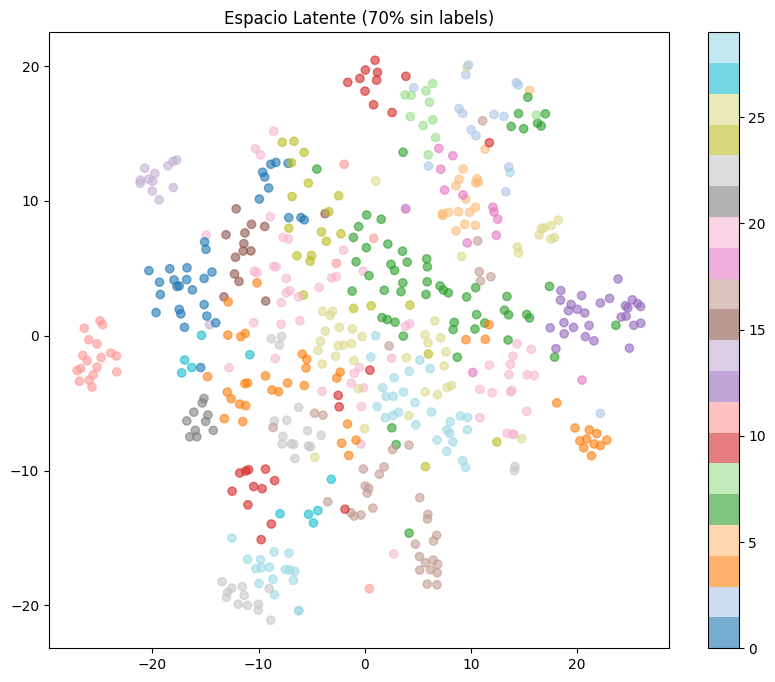

In [5]:
# t-SNE
tsne = TSNE(n_components=2, random_state=42)
latent_2d = tsne.fit_transform(latent_vectors.numpy())

# K-Means
kmeans = KMeans(n_clusters=30, random_state=42)
clusters = kmeans.fit_predict(latent_vectors.numpy())

# Visualización
plt.figure(figsize=(10, 8))
plt.scatter(latent_2d[:, 0], latent_2d[:, 1], c=clusters, cmap='tab20', alpha=0.6)
plt.colorbar()
plt.title("Espacio Latente (70% sin labels)")
plt.show()